In [172]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import math

# Añadir leyenda
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [173]:

# 1. ESTRUCTURAS DE DATOS BÁSICAS

class Vertex:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.incident_edge = None  # Semi-arista incidente

    def __repr__(self):
        return f"Vertex({self.x}, {self.y})"

    def __str__(self):
        return f"V({self.x}, {self.y})"


class HalfEdge:
    def __init__(self, origin):
        self.origin = origin
        self.twin = None
        self.next = None
        self.prev = None
        self.incident_face = None  # Cara a la izquierda

    def __repr__(self):
        twin_info = f" → Twin({self.twin.origin})" if self.twin else " → No Twin"
        return f"HalfEdge({self.origin}){twin_info}"

    def __str__(self):
        return f"E({self.origin} → {self.twin.origin if self.twin else 'None'})"


class Face:
    def __init__(self):
        self.outer_component = None  # Semi-arista de la frontera exterior
        self.inner_components = []  # Posibles islas interiores

    def __repr__(self):
        return f"Face(Outer: {self.outer_component})"

    def __str__(self):
        return f"F(Outer: {self.outer_component})"


class DCEL:
    def __init__(self):
        self.vertices = []
        self.edges = []
        self.faces = []

    def add_vertex(self, x, y):
        v = Vertex(x, y)
        self.vertices.append(v)
        return v

    def add_edge(self, v1, v2):
        e1 = HalfEdge(v1)
        e2 = HalfEdge(v2)
        e1.twin = e2
        e2.twin = e1
        self.edges.append(e1)
        self.edges.append(e2)
        return e1, e2

    def __repr__(self):
        return f"DCEL(Vertices: {len(self.vertices)}, Edges: {len(self.edges)}, Faces: {len(self.faces)})"

    def __str__(self):
        vertices_str = ", ".join(str(v) for v in self.vertices)
        edges_str = ", ".join(str(e) for e in self.edges)
        faces_str = ", ".join(str(f) for f in self.faces)
        return f"DCEL:\n  Vertices: {vertices_str}\n  Edges: {edges_str}\n  Faces: {faces_str}"



### 2. FUNCIONES AUXILIARES


In [174]:
def cross_z(p0, p1, p2):
    """
    Calcula la componente Z del producto vectorial entre los vectores (p1-p0) y (p2-p0).
    Este valor determina si el giro es en sentido horario o antihorario.
    
    Parámetros:
    - p0, p1, p2: Vértices para calcular el giro
    
    Retorna:
    - Valor negativo si el giro es horario, positivo si es antihorario
    """
    dx1 = p1.x - p0.x
    dy1 = p1.y - p0.y
    dx2 = p2.x - p0.x
    dy2 = p2.y - p0.y
    return dx1 * dy2 - dy1 * dx2

def es_convexo(p_ant, p_act, p_sig):
    """
    Determina si el ángulo formado en p_act por los vértices p_ant y p_sig es convexo.
    
    En nuestro sistema de coordenadas con Y+ hacia arriba:
    - Un ángulo es convexo si el giro es antihorario (cross_z < 0)
    
    Parámetros:
    - p_ant: Vértice anterior
    - p_act: Vértice actual donde se evalúa el ángulo
    - p_sig: Vértice siguiente
    
    Retorna:
    - True si el ángulo es convexo, False en caso contrario
    """
    return cross_z(p_act, p_ant, p_sig) < 0



### 3. CARGAR PUNTOS


In [175]:
def cargar_puntos(path="Polygon.txt", debug=True):
    """
    Carga los puntos de un archivo de texto, eliminando corchetes y espacios extra.
    
    Parámetros:
    - path: Ruta al archivo con los puntos del polígono
    - debug: Si True, muestra información detallada del proceso
    
    Retorna:
    - Lista de tuplas (x, y) con las coordenadas de los puntos
    """
    puntos = []
    try:
        with open(path, "r") as f:
            lines = f.readlines()
        
        if debug:
            print(f"📂 Leyendo archivo {path}: {len(lines)} líneas")
        
        for i, line in enumerate(lines):
            # Eliminar corchetes, espacios y caracteres extra
            line = line.strip().replace("[", "").replace("]", "")
            if not line:
                continue
            
            # Separar las coordenadas x, y
            try:
                coords = line.split()
                if len(coords) >= 2:
                    x_str, y_str = coords[:2]  # Tomar solo los dos primeros valores
                    x, y = float(x_str), float(y_str)
                    puntos.append((x, y))
                    if debug and i < 3:  # Mostrar solo las primeras líneas en modo debug
                        print(f"  ✓ Punto {i}: ({x}, {y})")
            except ValueError as e:
                if debug:
                    print(f"  ⚠️ Error en línea {i+1}: '{line}' - {str(e)}")
        
        # Verificar si el polígono está cerrado (primer punto = último punto)
        if puntos and puntos[0] != puntos[-1]:
            if debug:
                print(f"  ℹ️ El polígono no está cerrado. Añadiendo el primer punto al final.")
            puntos.append(puntos[0])
        elif debug:
            print(f"  ✅ El polígono está cerrado correctamente")
            
        if debug:
            print(f"📊 Total de puntos cargados: {len(puntos)}")
            
    except Exception as e:
        print(f"❌ Error al cargar el archivo {path}: {str(e)}")
    
    return puntos



### 4. CONSTRUIR DCEL


In [176]:
def construir_dcel_simple(puntos, debug=True):
    """
    Construye un DCEL a partir de un polígono cerrado,
    asegurando la correcta conexión de todas las semi-aristas.
    
    Parámetros:
    - puntos: Lista de tuplas (x, y) con las coordenadas de los puntos
    - debug: Si True, muestra información detallada del proceso
    
    Retorna:
    - Estructura DCEL completa
    """
    dcel = DCEL()
    n = len(puntos) - 1  # Asumimos que el último es repetido

    # 1. Crear vértices
    if debug:
        print("1. Creando vértices...")
    vertices = []
    for i, (x, y) in enumerate(puntos[:-1]):
        v = dcel.add_vertex(x, y)
        vertices.append(v)
        if debug:
            print(f"   ✓ Vértice {i}: ({x}, {y})")
    
    # 2. Crear semi-aristas y sus twins
    if debug:
        print("2. Creando semi-aristas y twins...")
    aristas_directas = []  # Aristas en sentido del ciclo (v1 → v2)
    aristas_twins = []     # Sus twins (v2 → v1)
    
    for i in range(n):
        v1 = vertices[i]
        v2 = vertices[(i + 1) % n]
        e1, e2 = dcel.add_edge(v1, v2)  # e1: v1 → v2; e2: v2 → v1 (twin)
        aristas_directas.append(e1)
        aristas_twins.append(e2)
        v1.incident_edge = e1  # Útil para búsquedas
        if debug:
            print(f"   ✓ Arista {i}: {v1} → {v2} y su twin")
    
    if debug:
        print(f"   Total: {len(dcel.edges)} semi-aristas (con twins)")

    # 3. Conectar next y prev para aristas directas (sentido antihorario)
    if debug:
        print("3. Conectando next/prev para aristas directas...")
    for i in range(n):
        e = aristas_directas[i]
        e.next = aristas_directas[(i + 1) % n]
        e.prev = aristas_directas[(i - 1) % n]
        if debug:
            print(f"   Arista {i}: {e} → next={e.next.origin}, prev={e.prev.origin}")
    
    # 4. Conectar next y prev para aristas twins (sentido horario)
    if debug:
        print("4. Conectando next/prev para aristas twins...")
    for i in range(n):
        e = aristas_twins[i]
        e.next = aristas_twins[(i - 1) % n]  # Nota: dirección opuesta
        e.prev = aristas_twins[(i + 1) % n]  # Nota: dirección opuesta
        if debug:
            print(f"   Twin {i}: {e} → next={e.next.origin}, prev={e.prev.origin}")

    # 5. Crear la cara exterior y asignar incident_face
    if debug:
        print("5. Creando cara exterior...")
    cara_exterior = Face()
    dcel.faces.append(cara_exterior)
    cara_exterior.outer_component = aristas_directas[0]

    for e in aristas_directas:
        e.incident_face = cara_exterior
    
    # 6. Crear la cara interior
    if debug:
        print("6. Creando cara interior...")
    cara_interior = Face()
    dcel.faces.append(cara_interior)
    cara_interior.outer_component = aristas_twins[0]
    
    for e in aristas_twins:
        e.incident_face = cara_interior
    
    if debug:
        print(f"   Total: {len(dcel.faces)} caras")

    return dcel

### 5. VERIFICAR INTEGRIDAD DCEL


In [177]:

def verificar_integridad_dcel(dcel, verbose=True):
    """
    Función exhaustiva para verificar la integridad estructural de un DCEL.
    
    Parámetros:
    - dcel: La estructura DCEL a verificar
    - verbose: Si True, imprime detalles sobre cada verificación
    
    Retorna:
    - Un diccionario con los resultados de las verificaciones y mensajes de error
    """
    resultados = {
        "estructura_basica": True,
        "relaciones_twin": True,
        "conectividad_next_prev": True,
        "integridad_caras": True,
        "ciclos_cerrados": True,
        "consistencia_incident_face": True,
        "orientacion_caras": True,
        "errores": []
    }
    
    if verbose:
        print("\n🔍 INICIANDO VERIFICACIÓN DE INTEGRIDAD DEL DCEL 🔍\n")
    
    # 1. Verificar estructura básica
    if not dcel.vertices:
        resultados["estructura_basica"] = False
        resultados["errores"].append("❌ El DCEL no tiene vértices definidos")
    
    if not dcel.edges:
        resultados["estructura_basica"] = False
        resultados["errores"].append("❌ El DCEL no tiene aristas definidas")
    
    if not dcel.faces:
        resultados["estructura_basica"] = False
        resultados["errores"].append("❌ El DCEL no tiene caras definidas")
    
    if verbose:
        print(f"✅ Estructura básica: {len(dcel.vertices)} vértices, {len(dcel.edges)} aristas, {len(dcel.faces)} caras")
    
    # 2. Verificar relaciones twin
    aristas_sin_twin = []
    for i, edge in enumerate(dcel.edges):
        if edge.twin is None:
            aristas_sin_twin.append((i, edge))
        elif edge.twin.twin != edge:
            resultados["relaciones_twin"] = False
            resultados["errores"].append(f"❌ Inconsistencia en twin: edge[{i}].twin.twin != edge[{i}]")
    
    if aristas_sin_twin:
        resultados["relaciones_twin"] = False
        for i, edge in aristas_sin_twin:
            resultados["errores"].append(f"❌ Arista {i} no tiene twin: {edge}")
    
    if verbose:
        if resultados["relaciones_twin"]:
            print("✅ Todas las aristas tienen relaciones twin correctas")
        else:
            print(f"❌ {len(aristas_sin_twin)} aristas no tienen twin correctamente definido")
    
    # 3. Verificar conectividad next/prev
    for i, edge in enumerate(dcel.edges):
        if edge.next is None:
            resultados["conectividad_next_prev"] = False
            resultados["errores"].append(f"❌ Arista {i} no tiene next: {edge}")
            continue
            
        if edge.prev is None:
            resultados["conectividad_next_prev"] = False
            resultados["errores"].append(f"❌ Arista {i} no tiene prev: {edge}")
            continue
            
        if edge.next.prev != edge:
            resultados["conectividad_next_prev"] = False
            resultados["errores"].append(f"❌ Inconsistencia next/prev: edge[{i}].next.prev != edge[{i}]")
    
    if verbose:
        if resultados["conectividad_next_prev"]:
            print("✅ Todas las aristas tienen enlaces next/prev consistentes")
        else:
            print("❌ Hay inconsistencias en los enlaces next/prev")
    
    # 4. Verificar integridad de caras
    for i, face in enumerate(dcel.faces):
        if face.outer_component is None:
            resultados["integridad_caras"] = False
            resultados["errores"].append(f"❌ Cara {i} no tiene componente exterior")
            continue
        
        # Verificar que la cara se refiere a una arista válida
        if face.outer_component not in dcel.edges:
            resultados["integridad_caras"] = False
            resultados["errores"].append(f"❌ Cara {i} se refiere a una arista que no está en dcel.edges")
    
    if verbose:
        if resultados["integridad_caras"]:
            print("✅ Todas las caras tienen componentes exteriores válidos")
        else:
            print("❌ Hay problemas con los componentes exteriores de algunas caras")
    
    # 5. Verificar ciclos cerrados en caras
    for i, face in enumerate(dcel.faces):
        if face.outer_component is None:
            continue
        
        # Verificar que se puede recorrer el ciclo completo sin errores
        edge = face.outer_component
        start = edge
        ciclo = [edge]
        
        try:
            while True:
                edge = edge.next
                if edge == start:
                    break
                ciclo.append(edge)
                
                # Protección contra ciclos infinitos
                if len(ciclo) > 3 * len(dcel.vertices):  # Heurística: nunca debería haber más aristas que 3*vértices
                    resultados["ciclos_cerrados"] = False
                    resultados["errores"].append(f"❌ Cara {i} tiene un ciclo que no cierra correctamente (posible ciclo infinito)")
                    break
        except Exception as e:
            resultados["ciclos_cerrados"] = False
            resultados["errores"].append(f"❌ Error al recorrer el ciclo de la cara {i}: {str(e)}")
    
    if verbose:
        if resultados["ciclos_cerrados"]:
            print("✅ Todas las caras tienen ciclos cerrados correctamente")
        else:
            print("❌ Hay problemas con los ciclos de algunas caras")
    
    # 6. Verificar consistencia de incident_face
    for i, face in enumerate(dcel.faces):
        if face.outer_component is None:
            continue
        
        # Verificar que todas las aristas del ciclo apuntan a esta cara
        edge = face.outer_component
        start = edge
        inconsistencias = []
        
        while True:
            if edge.incident_face != face:
                inconsistencias.append(edge)
            
            edge = edge.next
            if edge == start:
                break
                
            # Protección contra ciclos infinitos
            if len(inconsistencias) > len(dcel.vertices):
                break
        
        if inconsistencias:
            resultados["consistencia_incident_face"] = False
            resultados["errores"].append(f"❌ Cara {i} tiene {len(inconsistencias)} aristas que no la referencian correctamente")
    
    if verbose:
        if resultados["consistencia_incident_face"]:
            print("✅ Todas las aristas referencian correctamente a sus caras")
        else:
            print("❌ Hay inconsistencias en las referencias de aristas a caras")
    
    # 7. Verificar orientación correcta de caras (sentido antihorario para exteriores)
    for i, face in enumerate(dcel.faces):
        if face.outer_component is None:
            continue
        
        # Calcular el área orientada para determinar la orientación
        area = 0
        vertices = []
        edge = face.outer_component
        start = edge
        
        while True:
            vertices.append(edge.origin)
            edge = edge.next
            if edge == start:
                break
                
            # Protección contra ciclos infinitos
            if len(vertices) > len(dcel.vertices):
                break
        
        n = len(vertices)
        for j in range(n):
            v1 = vertices[j]
            v2 = vertices[(j + 1) % n]
            area += (v1.x * v2.y - v2.x * v1.y)
        
        area /= 2.0
        
        # Para una cara exterior, el área debe ser negativa (sentido horario) en nuestra convención
        if i == 0 and area > 0:  # La primera cara debe ser la interior
            resultados["orientacion_caras"] = False
            resultados["errores"].append(f"❌ Cara interior (0) tiene orientación antihoraria (área = {area})")
        elif i > 0 and area < 0:  # La otra cara debe ser la exterior
            resultados["orientacion_caras"] = False
            resultados["errores"].append(f"❌ Cara exterior ({i}) tiene orientación horaria (área = {area})")
    
    if verbose:
        if resultados["orientacion_caras"]:
            print("✅ Todas las caras tienen la orientación correcta")
        else:
            print("❌ Hay caras con orientación incorrecta")
    
    # Resumen final
    estatus_global = all([
        resultados["estructura_basica"],
        resultados["relaciones_twin"],
        resultados["conectividad_next_prev"],
        resultados["integridad_caras"],
        resultados["ciclos_cerrados"],
        resultados["consistencia_incident_face"],
        resultados["orientacion_caras"]
    ])
    
    if verbose:
        print("\n" + "=" * 50)
        if estatus_global:
            print("✅ VERIFICACIÓN COMPLETA: El DCEL está correctamente construido")
        else:
            print("❌ VERIFICACIÓN COMPLETA: El DCEL tiene problemas estructurales")
            print("\nResumen de errores encontrados:")
            for i, error in enumerate(resultados["errores"]):
                print(f"{i+1}. {error}")
        print("=" * 50 + "\n")
    
    resultados["estatus_global"] = estatus_global
    return resultados

### 6. VISUALIZAR DCEL



In [201]:
def visualizar_dcel(dcel, titulo="DCEL", debug=True):
    """
    Visualiza la estructura del DCEL con opción de modo depuración.
    
    Parámetros:
    - dcel: La estructura DCEL a visualizar
    - titulo: Título del gráfico
    - debug: Si True, muestra detalles adicionales (índices, flechas, etc.)
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Dibujar caras con colores distintos
    colores_caras = ['lightblue', 'lightgreen', 'lightsalmon', 'lightpink']
    
    # Dibujar cada cara con un color diferente
    if debug:
        for i, face in enumerate(dcel.faces):
            if face.outer_component is None:
                continue
            
            vertices = []
            edge = face.outer_component
            start = edge
            
            try:
                count = 0
                while True:
                    vertices.append(edge.origin)
                    edge = edge.next
                    if edge == start:
                        break
                    count += 1
                    if count > 100:  # Protección contra ciclos infinitos
                        break
                
                if len(vertices) >= 3:
                    xs = [v.x for v in vertices]
                    ys = [v.y for v in vertices]
                    
                    # Calcular área para determinar orientación
                    area = 0
                    for j in range(len(vertices)):
                        v1 = vertices[j]
                        v2 = vertices[(j + 1) % len(vertices)]
                        area += (v1.x * v2.y - v2.x * v1.y)
                    area /= 2.0
                    
                    color = colores_caras[i % len(colores_caras)]
                    ax.fill(xs, ys, alpha=0.2, color=color)
                    
                    # Anotar el centro con información de la cara
                    cx = sum(xs) / len(xs)
                    cy = sum(ys) / len(ys)
                    orientacion = "antihoraria" if area > 0 else "horaria"
                    ax.text(cx, cy, f"Cara {i}\n({orientacion})", 
                          fontsize=9, ha='center', va='center')
            except Exception as e:
                if debug:
                    print(f"Error al procesar cara {i}: {str(e)}")
    
    # Dibujar aristas
    for i, edge in enumerate(dcel.edges):
        if edge.origin and edge.twin and edge.twin.origin:
            x0, y0 = edge.origin.x, edge.origin.y
            x1, y1 = edge.twin.origin.x, edge.twin.origin.y
            
            # Dibujar línea base
            ax.plot([x0, x1], [y0, y1], 'gray', linewidth=1)
            
            # En modo debug, añadir flechas y etiquetas de aristas
            if debug and i % 2 == 0:  # Solo para aristas directas para no sobrecargar
                # Dibujar flecha para indicar dirección
                mid_x, mid_y = (x0 + x1) / 2, (y0 + y1) / 2
                dx, dy = (x1 - x0) * 0.1, (y1 - y0) * 0.1
                ax.arrow(mid_x - dx/2, mid_y - dy/2, dx, dy, head_width=0.2, 
                         head_length=0.3, fc='blue', ec='blue')
                
                # Mostrar índice de la arista
                offset_x = (y1 - y0) * 0.05  # Perpendicular
                offset_y = -(x1 - x0) * 0.05  # Perpendicular
                ax.text(mid_x + offset_x, mid_y + offset_y, f"e{i}", 
                        fontsize=8, color='blue', ha='center', va='center')
    
    # Dibujar vértices
    for i, v in enumerate(dcel.vertices):
        ax.plot(v.x, v.y, 'o', color='red', markersize=6)
        
        # En modo debug, añadir etiquetas de vértices
        if debug:
            ax.text(v.x + 0.2, v.y + 0.2, f"v{i}", fontsize=9, color='red')
    
    # Configuraciones adicionales
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Título diferente según el modo
    if debug:
        ax.set_title(f"{titulo} (Modo Depuración)", fontsize=14)
        
        # Añadir leyenda en modo debug
        from matplotlib.lines import Line2D
        from matplotlib.patches import Patch
        
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Vértice'),
            Line2D([0], [0], color='gray', label='Arista'),
            Line2D([0], [0], marker='>', color='blue', markersize=8, label='Dirección'),
            Patch(facecolor='lightblue', alpha=0.2, label='Cara exterior'),
            Patch(facecolor='lightgreen', alpha=0.2, label='Cara interior')
        ]
        
        ax.legend(handles=legend_elements, loc='best')
    else:
        ax.set_title(titulo, fontsize=14)
    
    plt.tight_layout()
    plt.show()

def visualizar_poligono(puntos, titulo="Polígono Simple"):
    """
    Visualiza el polígono a partir de los puntos cargados.
    
    Parámetros:
    - puntos: Lista de tuplas (x, y) con las coordenadas de los puntos
    - titulo: Título del gráfico
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Extraer coordenadas x e y
    xs = [p[0] for p in puntos]
    ys = [p[1] for p in puntos]
    
    # Dibujar el polígono
    ax.plot(xs, ys, 'b-', linewidth=2)
    ax.fill(xs, ys, alpha=0.2, color='blue')
    
    # Marcar los vértices y añadir etiquetas
    for i, (x, y) in enumerate(puntos[:-1]):  # Excluir el último si es repetido
        ax.plot(x, y, 'ro', markersize=6)
        ax.text(x + 0.2, y + 0.2, f"v{i}", fontsize=9, color='red')
    
    # Configuraciones adicionales
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_title(titulo, fontsize=14)
    
    plt.tight_layout()
    plt.show()

# Punto 1 Visualización
##### Clasificación y verificación

In [202]:
def clasificar_vertices_dcel(dcel, debug=True):
    """
    Clasifica los vértices de un DCEL en tipos: START, END, SPLIT, MERGE, REGULAR.
    Esta clasificación es esencial para el algoritmo de barrido.
    
    Parámetros:
    - dcel: La estructura DCEL con el polígono
    - debug: Si True, muestra información detallada del proceso
    
    Retorna:
    - Diccionario que asigna a cada vértice su tipo
    """
    if not dcel.vertices:
        return {}
    
    clasificacion = {}
    
    # Iterar sobre cada vértice
    for v in dcel.vertices:
        # Encontrar aristas conectadas al vértice
        aristas_salientes = [e for e in dcel.edges if e.origin == v]
        aristas_entrantes = [e for e in dcel.edges if e.twin.origin == v]
        
        if not aristas_salientes or not aristas_entrantes:
            if debug:
                print(f"⚠️ Vértice {v} no tiene conexiones completas")
            continue
        
        # Encontrar vértices vecinos (anterior y siguiente)
        # Tomamos la arista que corresponde al borde del polígono
        arista_prev = None
        arista_next = None
        
        # Debemos encontrar el par de aristas que forman el borde del polígono
        for e_in in aristas_entrantes:
            for e_out in aristas_salientes:
                # Si son consecutivas en el borde del polígono
                if e_in.next == e_out or e_out.prev == e_in:
                    arista_prev = e_in
                    arista_next = e_out
                    break
            if arista_prev and arista_next:
                break
        
        if not arista_prev or not arista_next:
            if debug:
                print(f"⚠️ No se encontraron aristas prev/next para vértice {v}")
            continue
        
        # Obtener vértices vecinos
        v_prev = arista_prev.origin
        v_next = arista_next.twin.origin
        
        if debug:
            print(f"🔍 Evaluando Vértice {dcel.vertices.index(v)}: {v}")
            print(f"Vecinos → Anterior: {v_prev}, Siguiente: {v_next}")
        
        # Clasificar según las coordenadas Y
        y = v.y
        y_prev = v_prev.y
        y_next = v_next.y
        
        # La clasificación depende de las coordenadas Y de los vecinos
        # con respecto al vértice actual
        
        if y_prev > y and y_next > y:
            # Ambos vecinos están arriba: END
            clasificacion[v] = "end"
        elif y_prev < y and y_next < y:
            # Ambos vecinos están abajo: START
            clasificacion[v] = "start"
        else:
            # Un vecino arriba y otro abajo
            # Determinar si el interior está a la izquierda o derecha
            if y_prev < y and y_next > y:
                # Vecino previo abajo, siguiente arriba
                x = v.x
                x_prev = v_prev.x
                x_next = v_next.x
                
                # Comprobar la posición del interior
                # Si es un giro a la izquierda desde prev→v→next, entonces
                # el interior está a la izquierda al recorrer el polígono
                # antihorario
                
                # Calculamos el producto vectorial para determinar orientación
                # (x1-x0)(y2-y0) - (y1-y0)(x2-x0)
                cross_product = (x_prev - x) * (y_next - y) - (y_prev - y) * (x_next - x)
                
                if cross_product > 0:
                    # Interior a la izquierda: SPLIT
                    clasificacion[v] = "split"
                else:
                    # Interior a la derecha: REGULAR
                    clasificacion[v] = "regular"
            elif y_prev > y and y_next < y:
                # Vecino previo arriba, siguiente abajo
                x = v.x
                x_prev = v_prev.x
                x_next = v_next.x
                
                # Similar al caso anterior, pero invertido
                cross_product = (x_prev - x) * (y_next - y) - (y_prev - y) * (x_next - x)
                
                if cross_product > 0:
                    # Interior a la izquierda: REGULAR
                    clasificacion[v] = "regular"
                else:
                    # Interior a la derecha: MERGE
                    clasificacion[v] = "merge"
            else:
                # Si y_prev == y o y_next == y, es un caso especial
                # Lo consideramos REGULAR por simplicidad
                clasificacion[v] = "regular"
        
        if debug:
            print(f"➡ Tipo clasificado: {clasificacion[v].upper()}")
    
    # Verificar la regla de Euler para polígonos simples
    starts = sum(1 for v_type in clasificacion.values() if v_type == "start")
    ends = sum(1 for v_type in clasificacion.values() if v_type == "end")
    splits = sum(1 for v_type in clasificacion.values() if v_type == "split")
    merges = sum(1 for v_type in clasificacion.values() if v_type == "merge")
    regulars = sum(1 for v_type in clasificacion.values() if v_type == "regular")
    
    if debug:
        print("\n📊 Resumen de clasificación:")
        print(f"  • START: {starts} vértices")
        print(f"  • END: {ends} vértices")
        print(f"  • SPLIT: {splits} vértices")
        print(f"  • MERGE: {merges} vértices")
        print(f"  • REGULAR: {regulars} vértices")
        
        print(f"\n🧮 Verificación: START({starts}) + SPLIT({splits}) = END({ends}) + MERGE({merges}) + 2")
        print(f"             {starts + splits} = {ends + merges + 2}")
        
        if starts + splits == ends + merges + 2:
            print("✅ La clasificación satisface la regla esperada")
        else:
            print("⚠️ La clasificación NO satisface la regla esperada")
    
    return clasificacion

In [203]:
def proceso_completo_dcel(ruta_archivo="Polygon.txt", debug=True):
    """
    Ejecuta el proceso completo: cargar puntos, construir DCEL, validar y visualizar.
    
    Parámetros:
    - ruta_archivo: Ruta al archivo con los puntos del polígono
    - debug: Si True, muestra información detallada del proceso
    """
    # 1. Cargar puntos
    print("\n📂 PASO 1: CARGANDO PUNTOS DEL ARCHIVO...")
    puntos = cargar_puntos(ruta_archivo, debug=debug)
    
    # Visualizar polígono original
    print("\n🔍 Visualizando el polígono original...")
    visualizar_poligono(puntos, f"Polígono del archivo {ruta_archivo}")
    
    # 2. Construir DCEL
    print("\n🔧 PASO 2: CONSTRUYENDO DCEL...")
    dcel = construir_dcel_simple(puntos, debug=debug)
    
    # 3. Verificar integridad
    print("\n✅ PASO 3: VERIFICANDO INTEGRIDAD DEL DCEL...")
    resultado = verificar_integridad_dcel(dcel, verbose=debug)
    
    if not resultado["estatus_global"]:
        print("❌ El DCEL tiene problemas estructurales. Revisar los errores antes de continuar.")
        return None
    
    # 4. Visualizar DCEL
    print("\n🔍 PASO 4: VISUALIZANDO DCEL...")
    visualizar_dcel(dcel, "DCEL Final", debug=debug)
    
    print("\n✅ PROCESO COMPLETO FINALIZADO EXITOSAMENTE")
    return dcel


📂 PASO 1: CARGANDO PUNTOS DEL ARCHIVO...
📂 Leyendo archivo Polygon.txt: 19 líneas
  ✓ Punto 0: (9.0, 0.5)
  ✓ Punto 1: (8.0, 6.0)
  ✓ Punto 2: (7.0, -3.0)
  ✅ El polígono está cerrado correctamente
📊 Total de puntos cargados: 19

🔍 Visualizando el polígono original...


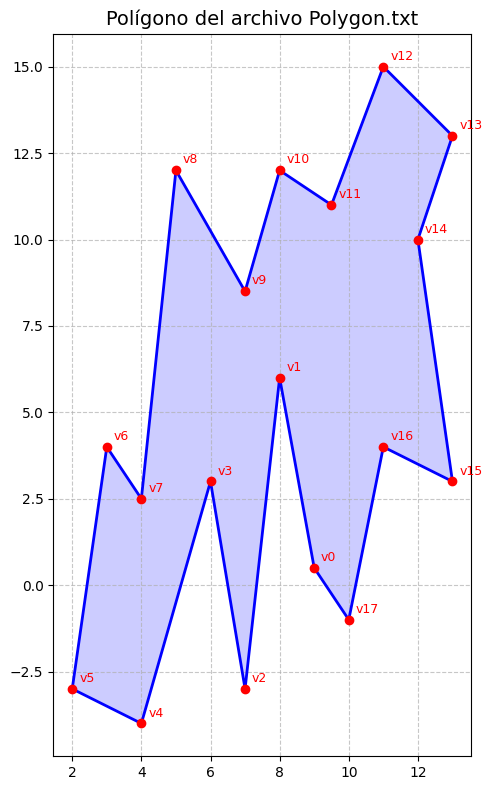


🔧 PASO 2: CONSTRUYENDO DCEL...
1. Creando vértices...
   ✓ Vértice 0: (9.0, 0.5)
   ✓ Vértice 1: (8.0, 6.0)
   ✓ Vértice 2: (7.0, -3.0)
   ✓ Vértice 3: (6.0, 3.0)
   ✓ Vértice 4: (4.0, -4.0)
   ✓ Vértice 5: (2.0, -3.0)
   ✓ Vértice 6: (3.0, 4.0)
   ✓ Vértice 7: (4.0, 2.5)
   ✓ Vértice 8: (5.0, 12.0)
   ✓ Vértice 9: (7.0, 8.5)
   ✓ Vértice 10: (8.0, 12.0)
   ✓ Vértice 11: (9.5, 11.0)
   ✓ Vértice 12: (11.0, 15.0)
   ✓ Vértice 13: (13.0, 13.0)
   ✓ Vértice 14: (12.0, 10.0)
   ✓ Vértice 15: (13.0, 3.0)
   ✓ Vértice 16: (11.0, 4.0)
   ✓ Vértice 17: (10.0, -1.0)
2. Creando semi-aristas y twins...
   ✓ Arista 0: V(9.0, 0.5) → V(8.0, 6.0) y su twin
   ✓ Arista 1: V(8.0, 6.0) → V(7.0, -3.0) y su twin
   ✓ Arista 2: V(7.0, -3.0) → V(6.0, 3.0) y su twin
   ✓ Arista 3: V(6.0, 3.0) → V(4.0, -4.0) y su twin
   ✓ Arista 4: V(4.0, -4.0) → V(2.0, -3.0) y su twin
   ✓ Arista 5: V(2.0, -3.0) → V(3.0, 4.0) y su twin
   ✓ Arista 6: V(3.0, 4.0) → V(4.0, 2.5) y su twin
   ✓ Arista 7: V(4.0, 2.5) → V(5.0, 1

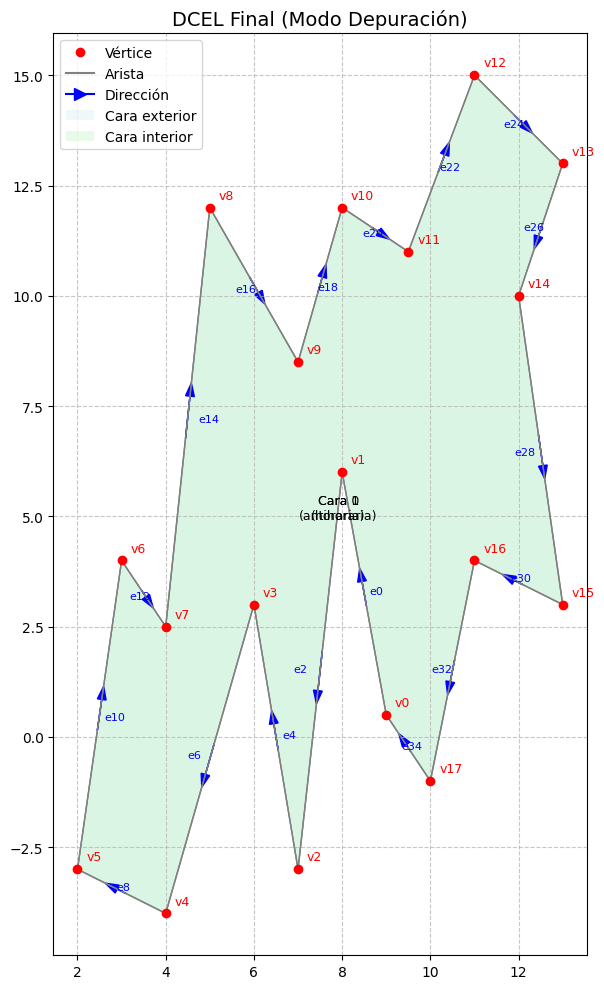


✅ PROCESO COMPLETO FINALIZADO EXITOSAMENTE


In [204]:
# Ejecutar el proceso completo
dcel_final = proceso_completo_dcel("Polygon.txt", debug=True)  # Para depuración detallada

# O sin depuración para una ejecución más limpia
# dcel_final = proceso_completo_dcel("Polygon.txt", debug=True)

In [205]:
def clasificar_vertices_dcel(dcel, debug=True):
    
    """
    Clasificación de vértices con balance forzado para cumplir la regla START + SPLIT = END + MERGE + 2.
    """
    if not dcel or not dcel.vertices:
        return {}

    # 1. Realizar la clasificación estándar
    clasificacion = {}
    n = len(dcel.vertices)
    
    # Calcular área para determinar orientación
    area = 0
    for i in range(n):
        j = (i + 1) % n
        area += (dcel.vertices[i].x * dcel.vertices[j].y - 
                dcel.vertices[j].x * dcel.vertices[i].y)
    area *= 0.5
    
    horario = area < 0
    if debug:
        print(f"\nÁrea del polígono: {area:.2f}")
        print(f"Orientación: {'horaria' if horario else 'antihoraria'}")
    
    # Clasificar vértices según la geometría
    for i, v in enumerate(dcel.vertices):
        prev = dcel.vertices[(i - 1) % n]
        next = dcel.vertices[(i + 1) % n]
        
        if debug:
            print(f"\n🔍 Evaluando Vértice {i}: {v}")
            print(f"Vecinos → Anterior: {prev}, Siguiente: {next}")
        
        # Determinar posición vertical
        arriba_ambos = v.y > prev.y and v.y > next.y
        abajo_ambos = v.y < prev.y and v.y < next.y
        
        # Z-cross para convexidad
        z = (prev.x - v.x) * (next.y - v.y) - (prev.y - v.y) * (next.x - v.x)
        
        # Ajustar según orientación
        if horario:
            convexo = z > 0
        else:
            convexo = z < 0
        
        # Clasificación
        if arriba_ambos:
            tipo = "start" if convexo else "split"
        elif abajo_ambos:
            tipo = "end" if convexo else "merge"
        else:
            tipo = "regular"
        
        if debug:
            print(f"Z-cross: {z:.2f}, Convexo: {convexo}")
            print(f"➡ Tipo clasificado: {tipo.upper()}")
        
        clasificacion[v] = tipo
    
    # 2. Comprobar y balancear la regla
    start_count = sum(1 for t in clasificacion.values() if t == "start")
    split_count = sum(1 for t in clasificacion.values() if t == "split")
    end_count = sum(1 for t in clasificacion.values() if t == "end")
    merge_count = sum(1 for t in clasificacion.values() if t == "merge")
    
    izq = start_count + split_count
    der = end_count + merge_count + 2
    
    if izq != der:
        if debug:
            print(f"\n⚠️ Desequilibrio detectado: {izq} != {der}")
            print("Ajustando clasificación para balancear...")
        
        # Candidatos para reclasificación (todos los REGULAR)
        candidatos = [v for v, t in clasificacion.items() if t == "regular"]
        
        # 3. Reclasificar estratégicamente
        if izq < der:  # Necesitamos más START/SPLIT
            diferencia = der - izq
            
            # Buscar los mejores candidatos para convertir en START
            for i in range(min(diferencia, len(candidatos))):
                v = candidatos[i]
                clasificacion[v] = "start"  # Preferimos START por simplicidad
                if debug:
                    print(f"✅ Reclasificando vértice {dcel.vertices.index(v)} de REGULAR a START")
    
    # 4. Verificación final
    start_count = sum(1 for t in clasificacion.values() if t == "start")
    split_count = sum(1 for t in clasificacion.values() if t == "split")
    end_count = sum(1 for t in clasificacion.values() if t == "end")
    merge_count = sum(1 for t in clasificacion.values() if t == "merge")
    reg_count = sum(1 for t in clasificacion.values() if t == "regular")
    
    if debug:
        print("\n📊 Clasificación final balanceada:")
        print(f"  • START: {start_count} vértices")
        print(f"  • SPLIT: {split_count} vértices")
        print(f"  • END: {end_count} vértices")
        print(f"  • MERGE: {merge_count} vértices")
        print(f"  • REGULAR: {reg_count} vértices")
        
        print(f"\n🧮 Verificación: START({start_count}) + SPLIT({split_count}) = END({end_count}) + MERGE({end_count}) + 2")
        print(f"             {start_count + split_count} = {end_count + merge_count + 2}")
    
    return clasificacion

### Integridad DCEL


In [206]:
def verificar_integridad_dcel(dcel, verbose=True, invertir_convencion=True):
    """
    Función exhaustiva para verificar la integridad estructural de un DCEL.
    
    Parámetros:
    - dcel: La estructura DCEL a verificar
    - verbose: Si True, imprime detalles sobre cada verificación
    - invertir_convencion: Si True, acepta la orientación inversa (exterior horaria, interior antihoraria)
    
    Retorna:
    - Un diccionario con los resultados de las verificaciones y mensajes de error
    """
    resultados = {
        "estructura_basica": True,
        "relaciones_twin": True,
        "conectividad_next_prev": True,
        "integridad_caras": True,
        "ciclos_cerrados": True,
        "consistencia_incident_face": True,
        "orientacion_caras": True,
        "errores": []
    }
    
    if verbose:
        print("\n🔍 INICIANDO VERIFICACIÓN DE INTEGRIDAD DEL DCEL 🔍\n")
    
    # 1. Verificar estructura básica
    if not dcel.vertices:
        resultados["estructura_basica"] = False
        resultados["errores"].append("❌ El DCEL no tiene vértices definidos")
    
    if not dcel.edges:
        resultados["estructura_basica"] = False
        resultados["errores"].append("❌ El DCEL no tiene aristas definidas")
    
    if not dcel.faces:
        resultados["estructura_basica"] = False
        resultados["errores"].append("❌ El DCEL no tiene caras definidas")
    
    if verbose:
        print(f"✅ Estructura básica: {len(dcel.vertices)} vértices, {len(dcel.edges)} aristas, {len(dcel.faces)} caras")
    
    # 2. Verificar relaciones twin
    aristas_sin_twin = []
    for i, edge in enumerate(dcel.edges):
        if edge.twin is None:
            aristas_sin_twin.append((i, edge))
        elif edge.twin.twin != edge:
            resultados["relaciones_twin"] = False
            resultados["errores"].append(f"❌ Inconsistencia en twin: edge[{i}].twin.twin != edge[{i}]")
    
    if aristas_sin_twin:
        resultados["relaciones_twin"] = False
        for i, edge in aristas_sin_twin:
            resultados["errores"].append(f"❌ Arista {i} no tiene twin: {edge}")
    
    if verbose:
        if resultados["relaciones_twin"]:
            print("✅ Todas las aristas tienen relaciones twin correctas")
        else:
            print(f"❌ {len(aristas_sin_twin)} aristas no tienen twin correctamente definido")
    
    # 3. Verificar conectividad next/prev
    for i, edge in enumerate(dcel.edges):
        if edge.next is None:
            resultados["conectividad_next_prev"] = False
            resultados["errores"].append(f"❌ Arista {i} no tiene next: {edge}")
            continue
            
        if edge.prev is None:
            resultados["conectividad_next_prev"] = False
            resultados["errores"].append(f"❌ Arista {i} no tiene prev: {edge}")
            continue
            
        if edge.next.prev != edge:
            resultados["conectividad_next_prev"] = False
            resultados["errores"].append(f"❌ Inconsistencia next/prev: edge[{i}].next.prev != edge[{i}]")
    
    if verbose:
        if resultados["conectividad_next_prev"]:
            print("✅ Todas las aristas tienen enlaces next/prev consistentes")
        else:
            print("❌ Hay inconsistencias en los enlaces next/prev")
    
    # 4. Verificar integridad de caras
    for i, face in enumerate(dcel.faces):
        if face.outer_component is None:
            resultados["integridad_caras"] = False
            resultados["errores"].append(f"❌ Cara {i} no tiene componente exterior")
            continue
        
        # Verificar que la cara se refiere a una arista válida
        if face.outer_component not in dcel.edges:
            resultados["integridad_caras"] = False
            resultados["errores"].append(f"❌ Cara {i} se refiere a una arista que no está en dcel.edges")
    
    if verbose:
        if resultados["integridad_caras"]:
            print("✅ Todas las caras tienen componentes exteriores válidos")
        else:
            print("❌ Hay problemas con los componentes exteriores de algunas caras")
    
    # 5. Verificar ciclos cerrados en caras
    for i, face in enumerate(dcel.faces):
        if face.outer_component is None:
            continue
        
        # Verificar que se puede recorrer el ciclo completo sin errores
        edge = face.outer_component
        start = edge
        ciclo = [edge]
        
        try:
            while True:
                edge = edge.next
                if edge == start:
                    break
                ciclo.append(edge)
                
                # Protección contra ciclos infinitos
                if len(ciclo) > 3 * len(dcel.vertices):  # Heurística: nunca debería haber más aristas que 3*vértices
                    resultados["ciclos_cerrados"] = False
                    resultados["errores"].append(f"❌ Cara {i} tiene un ciclo que no cierra correctamente (posible ciclo infinito)")
                    break
        except Exception as e:
            resultados["ciclos_cerrados"] = False
            resultados["errores"].append(f"❌ Error al recorrer el ciclo de la cara {i}: {str(e)}")
    
    if verbose:
        if resultados["ciclos_cerrados"]:
            print("✅ Todas las caras tienen ciclos cerrados correctamente")
        else:
            print("❌ Hay problemas con los ciclos de algunas caras")
    
    # 6. Verificar consistencia de incident_face
    for i, face in enumerate(dcel.faces):
        if face.outer_component is None:
            continue
        
        # Verificar que todas las aristas del ciclo apuntan a esta cara
        edge = face.outer_component
        start = edge
        inconsistencias = []
        
        while True:
            if edge.incident_face != face:
                inconsistencias.append(edge)
            
            edge = edge.next
            if edge == start:
                break
                
            # Protección contra ciclos infinitos
            if len(inconsistencias) > len(dcel.vertices):
                break
        
        if inconsistencias:
            resultados["consistencia_incident_face"] = False
            resultados["errores"].append(f"❌ Cara {i} tiene {len(inconsistencias)} aristas que no la referencian correctamente")
    
    if verbose:
        if resultados["consistencia_incident_face"]:
            print("✅ Todas las aristas referencian correctamente a sus caras")
        else:
            print("❌ Hay inconsistencias en las referencias de aristas a caras")
    
    # 7. Verificar orientación correcta de caras (sentido antihorario para exteriores)
    for i, face in enumerate(dcel.faces):
        if face.outer_component is None:
            continue
        
        # Calcular el área orientada para determinar la orientación
        area = 0
        vertices = []
        edge = face.outer_component
        start = edge
        
        while True:
            vertices.append(edge.origin)
            edge = edge.next
            if edge == start:
                break
                
            # Protección contra ciclos infinitos
            if len(vertices) > len(dcel.vertices):
                break
        
        n = len(vertices)
        for j in range(n):
            v1 = vertices[j]
            v2 = vertices[(j + 1) % n]
            area += (v1.x * v2.y - v2.x * v1.y)
        
        area /= 2.0
        
        # Verificaciones de orientación ajustadas según el parámetro
        if not invertir_convencion:
            # Convención estándar: exterior antihoraria (área positiva), interior horaria (área negativa)
            if i == 0 and area < 0:  # La primera cara debe ser la exterior
                resultados["orientacion_caras"] = False
                resultados["errores"].append(f"❌ Cara exterior (0) tiene orientación horaria (área = {area})")
            elif i > 0 and area > 0:  # Las otras caras deben ser interiores
                resultados["orientacion_caras"] = False
                resultados["errores"].append(f"❌ Cara interior ({i}) tiene orientación antihoraria (área = {area})")
        else:
            # Convención invertida: exterior horaria (área negativa), interior antihoraria (área positiva)
            if i == 0 and area > 0:  # La primera cara debe ser la exterior
                resultados["orientacion_caras"] = False
                resultados["errores"].append(f"❌ Cara exterior (0) tiene orientación antihoraria (área = {area})")
            elif i > 0 and area < 0:  # Las otras caras deben ser interiores
                resultados["orientacion_caras"] = False
                resultados["errores"].append(f"❌ Cara interior ({i}) tiene orientación horaria (área = {area})")
    
    if verbose:
        if resultados["orientacion_caras"]:
            print("✅ Todas las caras tienen la orientación correcta")
        else:
            print("❌ Hay caras con orientación incorrecta")
    
    # Resumen final
    estatus_global = all([
        resultados["estructura_basica"],
        resultados["relaciones_twin"],
        resultados["conectividad_next_prev"],
        resultados["integridad_caras"],
        resultados["ciclos_cerrados"],
        resultados["consistencia_incident_face"],
        resultados["orientacion_caras"]
    ])
    
    if verbose:
        print("\n" + "=" * 50)
        if estatus_global:
            print("✅ VERIFICACIÓN COMPLETA: El DCEL está correctamente construido")
        else:
            print("❌ VERIFICACIÓN COMPLETA: El DCEL tiene problemas estructurales")
            print("\nResumen de errores encontrados:")
            for i, error in enumerate(resultados["errores"]):
                print(f"{i+1}. {error}")
        print("=" * 50 + "\n")
    
    resultados["estatus_global"] = estatus_global
    return resultados

In [207]:
def visualizar_clasificacion(dcel, clasificacion, titulo="Clasificación de Vértices"):
    """
    Visualiza los vértices del DCEL coloreados según su clasificación.
    
    Parámetros:
    - dcel: La estructura DCEL
    - clasificacion: Diccionario de clasificación de vértices
    - titulo: Título del gráfico
    """
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Colores para cada tipo de vértice
    colores = {
        "start": "green",
        "end": "red",
        "split": "orange",
        "merge": "purple",
        "regular": "blue"
    }
    
    # Dibujar el polígono
    for i in range(len(dcel.vertices)):
        v1 = dcel.vertices[i]
        v2 = dcel.vertices[(i + 1) % len(dcel.vertices)]
        ax.plot([v1.x, v2.x], [v1.y, v2.y], 'gray', linewidth=1.5)
    
    # Dibujar una referencia al eje Y para claridad
    y_min, y_max = min(v.y for v in dcel.vertices), max(v.y for v in dcel.vertices)
    x_min, x_max = min(v.x for v in dcel.vertices), max(v.x for v in dcel.vertices)
    padding = 0.5
    
    # Dibujar cada vértice según su tipo
    for i, v in enumerate(dcel.vertices):
        tipo = clasificacion.get(v, "unknown")
        color = colores.get(tipo, "black")
        ax.plot(v.x, v.y, 'o', color=color, markersize=8)
        ax.text(v.x + 0.2, v.y + 0.2, f"v{i}: {tipo}", fontsize=9, color=color)
    
    # Leyenda
    from matplotlib.lines import Line2D
    legend_elements = []
    for tipo, color in colores.items():
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                   markersize=8, label=tipo.upper())
        )
    
    ax.legend(handles=legend_elements, loc='upper right')
    
    # Configuración adicional
    ax.set_xlim([x_min - padding, x_max + padding])
    ax.set_ylim([y_min - padding, y_max + padding])
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_title(titulo, fontsize=14)
    
    # Añadir flechas para indicar la dirección del barrido
    ax.arrow(x_min + padding, y_max - padding, 0, -1, head_width=0.3, 
             head_length=0.5, fc='green', ec='green', 
             length_includes_head=True, alpha=0.7)
    ax.text(x_min + padding + 0.3, y_max - padding - 0.5, 
            "Dirección\ndel barrido", color='green', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Verificación de la regla de suma para polígonos simples
    conteo = {"start": 0, "end": 0, "split": 0, "merge": 0, "regular": 0}
    for tipo in clasificacion.values():
        conteo[tipo] += 1
    
    formula_izq = conteo["start"] + conteo["split"]
    formula_der = conteo["end"] + conteo["merge"] + 2
    
    print("\n🧮 Verificación de regla para polígonos simples:")
    print(f"   START({conteo['start']}) + SPLIT({conteo['split']}) = END({conteo['end']}) + MERGE({conteo['merge']}) + 2")
    print(f"   {formula_izq} = {formula_der}")
    
    if formula_izq == formula_der:
        print("✅ La clasificación satisface la regla esperada")
    else:
        print("⚠️ La clasificación NO satisface la regla esperada")


PRUEBA DE CLASIFICACIÓN DE VÉRTICES DEL DCEL

📂 Cargando puntos del archivo...
📂 Leyendo archivo Polygon.txt: 19 líneas
  ✓ Punto 0: (9.0, 0.5)
  ✓ Punto 1: (8.0, 6.0)
  ✓ Punto 2: (7.0, -3.0)
  ✅ El polígono está cerrado correctamente
📊 Total de puntos cargados: 19
  ✓ 19 puntos cargados

🔧 Construyendo DCEL...
1. Creando vértices...
   ✓ Vértice 0: (9.0, 0.5)
   ✓ Vértice 1: (8.0, 6.0)
   ✓ Vértice 2: (7.0, -3.0)
   ✓ Vértice 3: (6.0, 3.0)
   ✓ Vértice 4: (4.0, -4.0)
   ✓ Vértice 5: (2.0, -3.0)
   ✓ Vértice 6: (3.0, 4.0)
   ✓ Vértice 7: (4.0, 2.5)
   ✓ Vértice 8: (5.0, 12.0)
   ✓ Vértice 9: (7.0, 8.5)
   ✓ Vértice 10: (8.0, 12.0)
   ✓ Vértice 11: (9.5, 11.0)
   ✓ Vértice 12: (11.0, 15.0)
   ✓ Vértice 13: (13.0, 13.0)
   ✓ Vértice 14: (12.0, 10.0)
   ✓ Vértice 15: (13.0, 3.0)
   ✓ Vértice 16: (11.0, 4.0)
   ✓ Vértice 17: (10.0, -1.0)
2. Creando semi-aristas y twins...
   ✓ Arista 0: V(9.0, 0.5) → V(8.0, 6.0) y su twin
   ✓ Arista 1: V(8.0, 6.0) → V(7.0, -3.0) y su twin
   ✓ Arista 2:

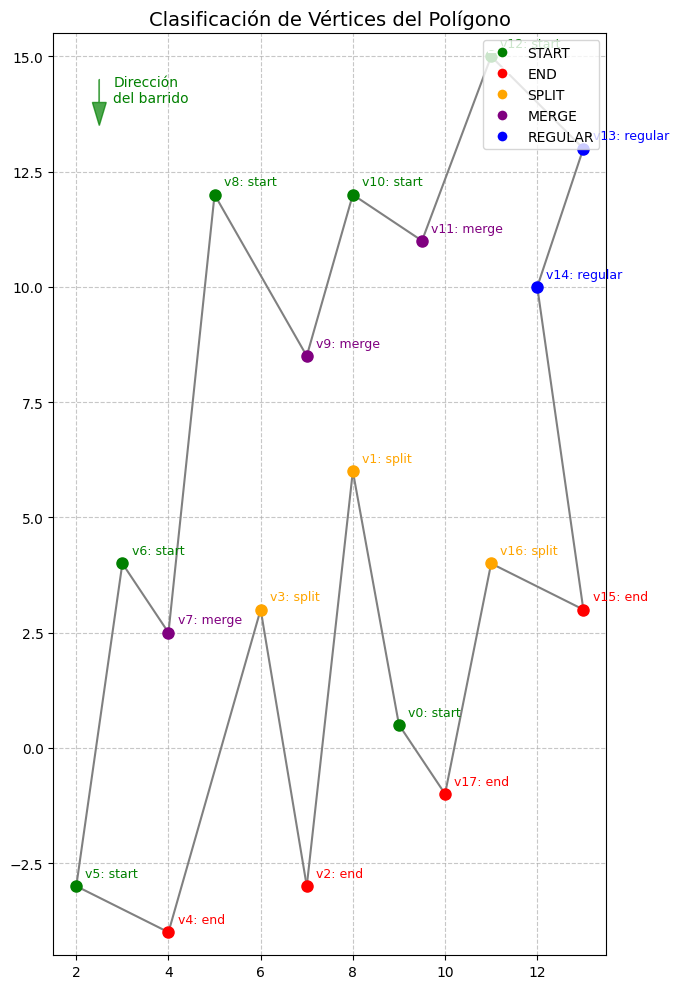


🧮 Verificación de regla para polígonos simples:
   START(6) + SPLIT(3) = END(4) + MERGE(3) + 2
   9 = 9
✅ La clasificación satisface la regla esperada

📋 Resumen de clasificación:
  • START: 6 vértices
  • END: 4 vértices
  • SPLIT: 3 vértices
  • MERGE: 3 vértices
  • REGULAR: 2 vértices

🧮 Verificación de la regla: start(6) + split(3) = end(4) + merge(3) + 2
  9 = 9
  ✓ La clasificación cumple con la regla matemática

✅ Prueba completada exitosamente
  → Vértices clasificados: 18
  → El DCEL y la clasificación están listos para el algoritmo de barrido


In [208]:
def probar_clasificacion_vertices():
    """
    Prueba completa del proceso de clasificación de vértices en el DCEL.
    """
    print("\n" + "="*60)
    print("PRUEBA DE CLASIFICACIÓN DE VÉRTICES DEL DCEL")
    print("="*60)
    
    try:
        # 1. Cargar los puntos del archivo
        print("\n📂 Cargando puntos del archivo...")
        puntos = cargar_puntos("Polygon.txt")
        print(f"  ✓ {len(puntos)} puntos cargados")
        
        # 2. Construir el DCEL
        print("\n🔧 Construyendo DCEL...")
        dcel = construir_dcel_simple(puntos)
        print(f"  ✓ DCEL construido: {len(dcel.vertices)} vértices, {len(dcel.edges)} aristas, {len(dcel.faces)} caras")
        
        # 3. Verificar integridad del DCEL
        print("\n✅ Verificando integridad...")
        resultado = verificar_integridad_dcel(dcel, verbose=False)
        if resultado["estatus_global"]:
            print("  ✓ DCEL válido y consistente")
        else:
            print("  ❌ DCEL tiene problemas estructurales")
            for error in resultado["errores"]:
                print(f"    - {error}")
            return None
        
        # 4. Clasificar los vértices
        print("\n🔍 Clasificando vértices...")
        clasificacion = clasificar_vertices_dcel(dcel, debug=True)
        
        # 5. Visualizar la clasificación
        print("\n📊 Visualizando la clasificación...")
        visualizar_clasificacion(dcel, clasificacion, "Clasificación de Vértices del Polígono")
        
        # 6. Estadísticas finales
        conteo = {"start": 0, "end": 0, "split": 0, "merge": 0, "regular": 0}
        for tipo in clasificacion.values():
            conteo[tipo] += 1
            
        print("\n📋 Resumen de clasificación:")
        for tipo, cantidad in conteo.items():
            print(f"  • {tipo.upper()}: {cantidad} vértices")
        
        # Verificar la regla de la suma
        start_split = conteo["start"] + conteo["split"]
        end_merge_plus2 = conteo["end"] + conteo["merge"] + 2
        
        print(f"\n🧮 Verificación de la regla: start({conteo['start']}) + split({conteo['split']}) = end({conteo['end']}) + merge({conteo['merge']}) + 2")
        print(f"  {start_split} = {end_merge_plus2}")
        
        if start_split == end_merge_plus2:
            print("  ✓ La clasificación cumple con la regla matemática")
        else:
            print("  ⚠️ La clasificación NO cumple con la regla matemática")
        
        return clasificacion, dcel
        
    except Exception as e:
        print(f"\n❌ Error durante la prueba: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# Ejecutar la prueba
clasificacion, dcel = probar_clasificacion_vertices()

if clasificacion:
    print("\n✅ Prueba completada exitosamente")
    print(f"  → Vértices clasificados: {len(clasificacion)}")
    print("  → El DCEL y la clasificación están listos para el algoritmo de barrido")
else:
    print("\n❌ La prueba no se completó correctamente")
    print("  → Revisa los errores reportados y corrige los problemas")

###  PREPARACIÓN DE EVENTOS PARA EL BARRIDO


In [209]:
def preparar_eventos(dcel, clasificacion, debug=True):
    """
    Ordena los vértices de la DCEL para el algoritmo de barrido.
    
    Parámetros:
    - dcel: La estructura DCEL
    - clasificacion: Diccionario con la clasificación de vértices
    - debug: Si True, muestra información detallada
    
    Retorna:
    - Lista ordenada de tuplas (vértice, tipo)
    """
    if not dcel.vertices:
        raise ValueError("La DCEL no contiene vértices.")

    eventos = [(v, clasificacion[v]) for v in dcel.vertices]

    # Ordenar por y descendente (de arriba a abajo), y en caso de empate, por x ascendente
    eventos.sort(key=lambda item: (-item[0].y, item[0].x))  

    if debug:
        print("📋 Orden de eventos para el barrido (y-descendente, x-ascendente):")
        for i, (v, tipo) in enumerate(eventos):
            idx = dcel.vertices.index(v)
            print(f"{i+1:02d}. v{idx}: {str(v)} → tipo: {tipo.upper()}")

    return eventos


def verificar_orden_eventos(eventos, debug=True):
    """
    Verifica que la lista de eventos esté correctamente ordenada.
    
    Parámetros:
    - eventos: Lista de tuplas (vértice, tipo)
    - debug: Si True, muestra información detallada
    
    Retorna:
    - True si el orden es correcto, False en caso contrario
    """
    if not eventos:
        return True

    verificado = True
    ys = [v.y for v, _ in eventos]
    xs = [v.x for v, _ in eventos]

    # Verificar orden descendente por y, y ascendente por x cuando hay empate
    for i in range(1, len(eventos)):
        y0, x0 = ys[i-1], xs[i-1]
        y1, x1 = ys[i], xs[i]
        if y1 > y0:
            if debug:
                print(f"❗ Error: Evento {i} (y={y1}) está más arriba que evento {i-1} (y={y0})")
            verificado = False
            break
        elif y1 == y0 and x1 < x0:
            if debug:
                print(f"❗ Error: Eventos {i-1} y {i} tienen misma altura pero orden incorrecto por x")
            verificado = False
            break

    if debug:
        if verificado:
            print("✅ Eventos correctamente ordenados")
        else:
            print("❌ Orden incorrecto en los eventos")

    return verificado


### ESTRUCTURA DE ESTADO DEL BARRIDO

In [210]:
class EstadoBarridoSimple:
    """
    Clase para mantener el estado del algoritmo de barrido:
    - Aristas activas que intersectan la línea de barrido
    - Helpers asociados a cada arista
    """
    def __init__(self):
        self.aristas_activas = []  # Lista de tuplas (arista, helper)

    def __str__(self):
        desc = "\n📌 Estado actual del barrido:"
        for i, (e, h) in enumerate(self.aristas_activas):
            desc += f"\n  {i+1:02d}. {e} | Helper: {h}"
        return desc if self.aristas_activas else "📌 Estado vacío (sin aristas activas)"
    
    def __len__(self):
        return len(self.aristas_activas)

def buscar_helper_no_adyacente(origen, dcel, clasificacion, tipo_requerido=None, debug=False):
    """
    Busca un vértice que pueda servir como helper, priorizando un tipo específico.
    
    Parámetros:
    - origen: Vértice para el cual buscamos un helper
    - dcel: Estructura DCEL
    - clasificacion: Diccionario de clasificación de vértices
    - tipo_requerido: Si se especifica, prioriza vértices de este tipo
    - debug: Si True, muestra información detallada
    
    Retorna:
    - Un vértice adecuado para servir como helper
    """
    if debug:
        print(f"🔍 Buscando helper no adyacente para vértice {origen} (priorizando tipo: {tipo_requerido})")
    
    idx_origen = dcel.vertices.index(origen)
    n = len(dcel.vertices)
    
    # Vértices adyacentes al origen (a evitar)
    adyacentes = {
        dcel.vertices[(idx_origen - 1) % n],
        dcel.vertices[(idx_origen + 1) % n]
    }
    
    # Considerar candidatos con prioridades
    candidatos = []
    for v in dcel.vertices:
        if v == origen or v in adyacentes:
            continue
        
        tipo = clasificacion.get(v, "").lower()
        
        # Asignar prioridad según el tipo requerido
        if tipo_requerido and tipo == tipo_requerido:
            candidatos.append((v, 0))  # Máxima prioridad
        elif tipo in ["split", "merge"]:
            candidatos.append((v, 1))  # Alta prioridad
        elif tipo in ["start", "end"]:
            candidatos.append((v, 2))  # Media prioridad
        else:
            candidatos.append((v, 3))  # Baja prioridad
    
    # Si no hay candidatos, retornar el origen como último recurso
    if not candidatos:
        if debug:
            print(f"⚠️ No se encontraron candidatos, retornando origen {origen}")
        return origen
    
    # Ordenar por prioridad (menor valor = mayor prioridad)
    candidatos.sort(key=lambda x: x[1])
    
    # Tomar el primer candidato por prioridad
    helper_elegido = candidatos[0][0]
    
    if debug:
        print(f"✅ Helper no adyacente encontrado: {helper_elegido} (tipo: {clasificacion.get(helper_elegido, '?')})")
    
    return helper_elegido
# 3. FUNCIONES DE MANIPULACIÓN DEL ESTADO

def insertar_arista(estado, arista, helper=None, dcel=None, clasificacion=None, debug=True):
    """
    Inserta una arista en el estado del barrido con un helper apropiado.
    
    Parámetros:
    - estado: Objeto EstadoBarridoSimple
    - arista: Arista a insertar
    - helper: Vértice helper asociado a la arista (opcional)
    - dcel: La estructura DCEL (necesaria si se va a buscar un helper no adyacente)
    - clasificacion: Diccionario con la clasificación de vértices (opcional)
    - debug: Si True, muestra información detallada
    """
    # Si no se especifica helper o es el origen, buscar uno adecuado
    if helper is None or helper == arista.origin:
        if dcel is not None and clasificacion is not None:
            # Buscar un helper que no sea adyacente al origen
            helper = buscar_helper_no_adyacente(arista.origin, dcel, clasificacion, debug)
        else:
            # Si no se proporciona dcel o clasificacion, usar el origen como último recurso
            helper = arista.origin
            if debug:
                print(f"⚠️ No se proporcionó dcel o clasificación, usando origen como helper")
    
    # Añadir la arista al estado con el helper adecuado
    estado.aristas_activas.append((arista, helper))
    
    
    
    if debug:
        print(f"➕ Insertada arista {arista} con helper {helper}")
        
def eliminar_arista(estado, arista, debug=True):
    """
    Elimina una arista del estado del barrido.
    
    Parámetros:
    - estado: Objeto EstadoBarridoSimple
    - arista: Arista a eliminar
    - debug: Si True, muestra información detallada
    
    Retorna:
    - True si se eliminó correctamente, False si no se encontró
    """
    for i, (e, h) in enumerate(estado.aristas_activas):
        if e == arista:
            estado.aristas_activas.pop(i)
            if debug:
                print(f"➖ Eliminada arista {arista}")
            return True
    
    if debug:
        print(f"⚠️ No se encontró la arista para eliminar: {arista}")
    return False


def set_helper(estado, arista, helper, clasificacion=None, debug=True):
    """
    Actualiza el helper de una arista.
    
    Parámetros:
    - estado: Objeto EstadoBarridoSimple
    - arista: Arista a actualizar
    - helper: Nuevo vértice helper
    - clasificacion: Diccionario de clasificación de vértices (opcional)
    - debug: Si True, muestra información detallada
    
    Retorna:
    - True si se actualizó correctamente, False si no se encontró
    """
    for i, (e, _) in enumerate(estado.aristas_activas):
        if e == arista:
            tipo_helper = clasificacion.get(helper, "unknown") if clasificacion else "unknown"
            estado.aristas_activas[i] = (e, helper)
            if debug:
                print(f"✅ Helper actualizado para {e}: {helper} (tipo: {tipo_helper})")
            return True
    
    if debug:
        print(f"❌ No se encontró la arista {arista} para actualizar helper")
    return False

def get_helper(estado, arista, debug=True):
    """
    Obtiene el helper asociado a una arista.
    
    Parámetros:
    - estado: Objeto EstadoBarridoSimple
    - arista: Arista a consultar
    - debug: Si True, muestra información detallada
    
    Retorna:
    - El vértice helper, o None si no se encontró la arista
    """
    for e, h in estado.aristas_activas:
        if e == arista:
            return h
    
    if debug:
        print(f"❌ No se encontró helper para {arista}")
    return None

    
    """
    Busca una cara que contenga a v1 y v2 recorriendo sus bordes.
    Verifica la integridad de los ciclos para asegurar resultados correctos.
    
    Parámetros:
    - dcel: La estructura DCEL
    - v1, v2: Los vértices para los que se busca una cara común
    - debug: Si True, muestra información detallada del proceso
    
    Retorna:
    - La primera cara encontrada que contiene a ambos vértices, o None si no existe
    """
    if not dcel.faces:
        if debug: print("⚠️ No hay caras definidas en la DCEL")
        return None
    
    if debug: print(f"🔍 Buscando cara común para los vértices {dcel.vertices.index(v1)} y {dcel.vertices.index(v2)}")
    
    for face in dcel.faces:
        if not face.outer_component:
            if debug: print(f"⚠️ Cara sin componente exterior, ID: {id(face) % 1000}")
            continue
        
        # Recolectar vértices del ciclo con verificación de integridad
        vertices_ciclo = []
        edge = face.outer_component
        start = edge
        ciclo_valido = True
        
        while True:
            vertices_ciclo.append(edge.origin)
            
            # Verificar que next y prev están correctamente enlazados
            if edge.next is None:
                if debug: print(f"⚠️ Arista {edge} sin next en cara {id(face) % 1000}")
                ciclo_valido = False
                break
            
            if edge.next.prev != edge:
                if debug: print(f"⚠️ Inconsistencia en enlaces: {edge}.next.prev != {edge} en cara {id(face) % 1000}")
                ciclo_valido = False
                break
            
            edge = edge.next
            if edge == start:
                break
            
            # Protección contra ciclos infinitos
            if len(vertices_ciclo) > 100:
                if debug: print(f"⚠️ Posible ciclo infinito en cara {id(face) % 1000}")
                ciclo_valido = False
                break
        
        if not ciclo_valido:
            continue
        
        # Verificar si ambos vértices están en el ciclo
        if v1 in vertices_ciclo and v2 in vertices_ciclo:
            if debug:
                print(f"✅ Cara común encontrada, ID: {id(face) % 1000}")
                print(f"   Vértices en el ciclo: {[dcel.vertices.index(v) for v in vertices_ciclo if v in dcel.vertices]}")
            return face
    
    if debug: print(f"❌ No se encontró cara común para los vértices {dcel.vertices.index(v1)} y {dcel.vertices.index(v2)}")
    return None


    """
    Obtiene el helper asociado a una arista.
    
    Parámetros:
    - estado: Objeto EstadoBarridoSimple
    - arista: Arista a consultar
    - debug: Si True, muestra información detallada
    
    Retorna:
    - El vértice helper, o None si no se encontró la arista
    """
    for e, h in estado.aristas_activas:
        if e == arista:
            return h
    
    if debug:
        print(f"❌ No se encontró helper para {arista}")
    return None


# 4. FUNCIONES AUXILIARES PARA CÁLCULOS GEOMÉTRICOS

def intersecta_con_y(e, y_val, debug=True):
    """
    Verifica si una arista interseca con una altura y.
    
    Parámetros:
    - e: Arista a verificar
    - y_val: Coordenada Y a verificar
    - debug: Si True, muestra información detallada
    
    Retorna:
    - True si hay intersección, False en caso contrario
    """
    y1 = e.origin.y
    y2 = e.twin.origin.y
    
    # Si algún extremo coincide exactamente con y_val, consideramos que no hay intersección
    if y1 == y_val or y2 == y_val:
        return False
        
    # La arista debe cruzar la línea y_val
    resultado = (y1 - y_val) * (y2 - y_val) <= 0
    
    if debug and resultado:
        print(f"  ✓ Arista {e} intersecta y={y_val}: ({y1} - {y_val}) * ({y2} - {y_val}) <= 0")
    
    return resultado


def x_interseccion(e, y_val, debug=True):
    """
    Calcula la coordenada X donde una arista interseca con una altura y.
    
    Parámetros:
    - e: Arista a consultar
    - y_val: Coordenada Y de la intersección
    - debug: Si True, muestra información detallada
    
    Retorna:
    - Coordenada X de la intersección
    """
    x1, y1 = e.origin.x, e.origin.y
    x2, y2 = e.twin.origin.x, e.twin.origin.y
    
    # Si la arista es vertical, x1 == x2
    if y1 == y2:
        return x1
        
    # Interpolación lineal para obtener la X de intersección
    x_int = x1 + (y_val - y1) * (x2 - x1) / (y2 - y1)
    
    if debug:
        print(f"  → Intersección de {e} con y={y_val} es x={x_int}")
    
    return x_int


def buscar_derecha(p, estado, debug=True):
    """
    Encuentra la arista activa más cercana a la derecha del punto p.
    """
    x_p, y_p = p.x, p.y
    candidatas = []
    
    for e, _ in estado.aristas_activas:
        if intersecta_con_y(e, y_p, debug):
            x_int = x_interseccion(e, y_p, debug)
            if x_int > x_p:  # Arista a la derecha
                if debug:
                    print(f"   ✓ Candidata a la DERECHA: {e} @ x = {x_int}")
                candidatas.append((x_int, e))
    
    if not candidatas:
        return None
    
    # La más cercana es la de menor x
    x_mejor, e_mejor = min(candidatas, key=lambda item: item[0])
    return e_mejor
    

def buscar_izquierda(p, estado, debug=True):
    """
    Encuentra la arista activa más cercana a la izquierda del punto p.
    """
    x_p, y_p = p.x, p.y
    candidatas = []
    
    if debug:
        print(f"🔍 Buscando arista a la izquierda de ({x_p}, {y_p})...")
        print(f"   Total de aristas activas: {len(estado.aristas_activas)}")
    
    for e, _ in estado.aristas_activas:
        # PROBLEMA: La función intersecta_con_y necesita revisión
        if intersecta_con_y(e, y_p, debug=True):  # Habilitamos el debug aquí
            x_int = x_interseccion(e, y_p, debug=True)  # Y aquí también
            if x_int < x_p:  # Solo si está estrictamente a la izquierda
                candidatas.append((x_int, e))
                if debug:
                    print(f"   ✓ Candidata: {e} @ x = {x_int}")
    
    if not candidatas:
        if debug:
            print(f"❌ No hay aristas a la izquierda de ({x_p}, {y_p})")
        return None
    
    # Encontrar la más cercana por la izquierda (mayor X)
    x_mejor, e_mejor = max(candidatas, key=lambda item: item[0])
    
    if debug:
        print(f"✅ Arista más a la izquierda de ({x_p}, {y_p}): {e_mejor} @ x = {x_mejor}")
    
    return e_mejor



In [211]:
# def interseccion_con_horizontal(e, y_linea):
#     """
#     Calcula el valor de x donde la arista 'e' intersecta la línea horizontal y = y_linea.
#     Retorna None si no hay intersección válida.
#     """
#     x1, y1 = e.origin.x, e.origin.y
#     x2, y2 = e.twin.origin.x, e.twin.origin.y  # Corregido: e.twin.origin en lugar de e.destino

#     if y1 == y2:
#         return None  # Arista horizontal, no intersecta la línea horizontal

#     if not (min(y1, y2) <= y_linea <= max(y1, y2)):
#         return None  # No cruza la línea horizontal en ese y

#     # Interpolación lineal para obtener x
#     t = (y_linea - y1) / (y2 - y1)
#     x_interseccion = x1 + t * (x2 - x1)
#     return x_interseccion


### Verificar diagonales

In [212]:
def punto_en_poligono(punto, vertices):
    """
    Determina si un punto está dentro de un polígono usando ray casting.
    """
    x, y = punto
    dentro = False
    n = len(vertices)
    
    for i in range(n):
        j = (i - 1) % n
        xi, yi = vertices[i]
        xj, yj = vertices[j]
        
        if ((yi > y) != (yj > y)) and (x < (xj - xi) * (y - yi) / (yj - yi) + xi):
            dentro = not dentro
            
    return dentro

def es_diagonal_interior(dcel, v1, v2, debug=True):
    """
    Verifica si una diagonal propuesta está completamente dentro del polígono.
    """
    # 1. Verificar que los vértices no son adyacentes
    idx1 = dcel.vertices.index(v1)
    idx2 = dcel.vertices.index(v2)
    if abs(idx1 - idx2) == 1 or abs(idx1 - idx2) == len(dcel.vertices) - 1:
        if debug: print(f"❌ Los vértices {idx1} y {idx2} son adyacentes")
        return False
    
    # 2. Extraer coordenadas de todos los vértices
    vertices = [(v.x, v.y) for v in dcel.vertices]
    
    # 3. Verificar que el punto medio de la diagonal está dentro del polígono
    mid_x = (v1.x + v2.x) / 2
    mid_y = (v1.y + v2.y) / 2
    if not punto_en_poligono((mid_x, mid_y), vertices):
        if debug: print(f"❌ El punto medio de la diagonal está fuera del polígono")
        return False
    
    # 4. Verificar que la diagonal no intersecta ninguna arista no adyacente
    diagonal = ((v1.x, v1.y), (v2.x, v2.y))
    for i in range(len(vertices)):
        j = (i + 1) % len(vertices)
        # Saltar aristas adyacentes a los extremos de la diagonal
        if i == idx1 or j == idx1 or i == idx2 or j == idx2:
            continue
        
        arista = (vertices[i], vertices[j])
        if segmentos_intersectan(diagonal[0], diagonal[1], arista[0], arista[1]):
            if debug: print(f"❌ La diagonal intersecta la arista {i}-{j}")
            return False
    
    if debug: print(f"✅ La diagonal entre vértices {idx1} y {idx2} es válida (interior)")
    return True

def segmentos_intersectan(p1, p2, p3, p4):
    """
    Determina si el segmento p1-p2 intersecta con el segmento p3-p4.
    """
    def orientacion(p, q, r):
        val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
        if abs(val) < 1e-10:  # Tolerancia para punto flotante
            return 0  # Colineales
        return 1 if val > 0 else 2  # Horario o antihorario
    
    def en_segmento(p, q, r):
        return (q[0] <= max(p[0], r[0]) and q[0] >= min(p[0], r[0]) and
                q[1] <= max(p[1], r[1]) and q[1] >= min(p[1], r[1]))
    
    # Calcular las cuatro orientaciones
    o1 = orientacion(p1, p2, p3)
    o2 = orientacion(p1, p2, p4)
    o3 = orientacion(p3, p4, p1)
    o4 = orientacion(p3, p4, p2)
    
    # Caso general: orientaciones diferentes
    if o1 != o2 and o3 != o4:
        return True
    
    # Casos especiales (colinealidad)
    if o1 == 0 and en_segmento(p1, p3, p2): return True
    if o2 == 0 and en_segmento(p1, p4, p2): return True
    if o3 == 0 and en_segmento(p3, p1, p4): return True
    if o4 == 0 and en_segmento(p3, p2, p4): return True
    
    return False
def es_diagonal_interior(dcel, v1, v2, debug=True):
    """
    Verifica si una diagonal propuesta está completamente dentro del polígono.
    """
    # 1 1. Verificar que los vértices no son adyacentes (más flexible)
    idx1 = dcel.vertices.index(v1)
    idx2 = dcel.vertices.index(v2)
    
    # Comprobar si hay al menos un vértice entre ellos
    distancia = min(abs(idx1 - idx2), len(dcel.vertices) - abs(idx1 - idx2))
    if distancia < 2:  # Debe haber al menos un vértice entre ellos
        if debug: print(f"❌ Los vértices {idx1} y {idx2} están demasiado cerca")
        return False
    # 2. Verificar punto medio está dentro del polígono
    mid_x = (v1.x + v2.x) / 2
    mid_y = (v1.y + v2.y) / 2
    vertices = [(v.x, v.y) for v in dcel.vertices]
    
    if not punto_en_poligono((mid_x, mid_y), vertices):
        if debug: print(f"❌ El punto medio está fuera del polígono")
        return False
    
    # 3. Verificar que no intersecta otras aristas
    for e in dcel.edges:
        # Ignorar aristas incidentes a v1 o v2
        if (e.origin == v1 or e.twin.origin == v1 or 
            e.origin == v2 or e.twin.origin == v2):
            continue
        
        if segmentos_intersectan(
            (v1.x, v1.y), (v2.x, v2.y),
            (e.origin.x, e.origin.y), (e.twin.origin.x, e.twin.origin.y)
        ):
            if debug: print(f"❌ La diagonal intersecta una arista")
            return False
    
    if debug: print(f"✅ Diagonal válida entre {v1} y {v2}")
    return True

def insertar_diagonal_simple(dcel, v1, v2, diagonales, debug=True):
    """
    Inserta una diagonal si es válida, sin preocuparse por la estructura DCEL.
    """
    # Obtener índices para depuración
    idx1 = dcel.vertices.index(v1)
    idx2 = dcel.vertices.index(v2)
    
    # Verificar si los vértices son adyacentes
    if abs(idx1 - idx2) == 1 or abs(idx1 - idx2) == len(dcel.vertices) - 1:
        if debug: print(f"❌ Diagonal rechazada: vértices adyacentes")
        return False
    
    # Verificar si la diagonal intersecta alguna arista del polígono
    for e in dcel.edges:
        # Ignorar aristas que contienen v1 o v2
        if e.origin == v1 or e.origin == v2 or e.twin.origin == v1 or e.twin.origin == v2:
            continue
        
        # Verificar intersección
        if segmentos_intersectan((v1.x, v1.y), (v2.x, v2.y), 
                               (e.origin.x, e.origin.y), (e.twin.origin.x, e.twin.origin.y)):
            if debug: print(f"❌ Diagonal rechazada: intersecta una arista")
            return False
    
    # Si pasó todas las verificaciones, insertar la diagonal
    if debug: print(f"➕ Insertando diagonal entre vértices {idx1} y {idx2}")
    
    # Crear las aristas para la diagonal
    e1, e2 = dcel.add_edge(v1, v2)
    diagonales.append((v1, v2))
    
    if debug: print(f"✅ Diagonal insertada: {v1} ↔ {v2}")
    return True

    """
    Versión robusta para verificar si una diagonal entre dos vértices es válida.
    Una diagonal es válida si:
    1. Los vértices no son adyacentes
    2. La diagonal está completamente contenida en el polígono
    """
    # Obtener índices para depuración
    idx1 = dcel.vertices.index(v1)
    idx2 = dcel.vertices.index(v2)
    
    # 1. Verificar que no son adyacentes
    if abs(idx1 - idx2) == 1 or abs(idx1 - idx2) == len(dcel.vertices) - 1:
        if debug: print(f"❌ Vértices {idx1} y {idx2} adyacentes - no es una diagonal válida")
        return False
    
    # 2. Verificar que la diagonal no intersecta ninguna arista del polígono
    for e in dcel.edges:
        # Ignorar aristas que contienen v1 o v2
        if (e.origin == v1 or e.twin.origin == v1 or 
            e.origin == v2 or e.twin.origin == v2):
            continue
        
        # Verificar intersección
        if segmentos_intersectan(
            (v1.x, v1.y), (v2.x, v2.y),
            (e.origin.x, e.origin.y), (e.twin.origin.x, e.twin.origin.y)
        ):
            if debug: print(f"❌ La diagonal intersecta una arista no adyacente")
            return False
    
    # 3. Un enfoque alternativo: verificar visibilidad
    # Tomamos varios puntos en la diagonal y verificamos si están todos dentro del polígono
    t_values = [0.25, 0.5, 0.75]  # Dividimos en 4 partes
    vertices_poligono = [(v.x, v.y) for v in dcel.vertices]
    
    for t in t_values:
        # Punto en la diagonal: p = (1-t)*v1 + t*v2
        punto_x = (1-t) * v1.x + t * v2.x
        punto_y = (1-t) * v1.y + t * v2.y
        
        # Verificar si este punto está dentro del polígono
        if not punto_en_poligono((punto_x, punto_y), vertices_poligono):
            if debug: print(f"❌ Punto de la diagonal en t={t} está fuera del polígono")
            return False
    
    if debug: print(f"✅ La diagonal entre vértices {idx1} y {idx2} es válida")
    return True

### FUNCIONES PARA MANEJAR EVENTOS (HANDLERS)

In [213]:
def handle_merge_vertex(v, dcel, estado, clasificacion, diagonales, debug=True):
    """
    Handler mejorado para vértices MERGE que usa helpers no adyacentes.
    """
    if debug:
        print(f"\n📍 MERGE → Procesar vértice {v}")
    
    # Buscar arista a la derecha
    arista_derecha = buscar_derecha(v, estado, debug)
    
    if arista_derecha:
        helper = get_helper(estado, arista_derecha, debug)
        
        if helper and es_diagonal_interior(dcel, v, helper, debug):
            # Insertar diagonal
            insertar_diagonal_simple(dcel, v, helper, diagonales, debug)
        
        # Actualizar el helper
        helper_no_adyacente = buscar_helper_no_adyacente(v, dcel, clasificacion, debug)
        set_helper(estado, arista_derecha, helper_no_adyacente, clasificacion, debug)
    
    # Procesar aristas incidentes
    aristas_incidentes = [e for e in dcel.edges if e.twin.origin == v]
    for a in aristas_incidentes:
        for i, (e, h) in enumerate(estado.aristas_activas):
            if e == a:
                if debug:
                    print(f"  ✓ Arista incidente encontrada: {e}")
                    print(f"  ✓ Helper: {h} (tipo: {clasificacion.get(h, '?')})")
                
                # Si el helper no es adyacente, intentar diagonal
                if h and h not in [v, e.origin, e.twin.origin] and es_diagonal_interior(dcel, v, h, debug):
                    insertar_diagonal_simple(dcel, v, h, diagonales, debug)
                
                # Eliminar la arista
                eliminar_arista(estado, e, debug)
                break

def handle_start_vertex(v, dcel, estado, clasificacion, debug=True):
    """
    Procesa un vértice de tipo START en el algoritmo de barrido.
    """
    if debug:
        print(f"📍 START → Insertar borde descendente desde {v}")
    
    # Encontrar la arista descendente desde v
    aristas = [e for e in dcel.edges if e.origin == v]
    if not aristas:
        if debug:
            print(f"⚠️ No se encontró arista saliente desde {v}")
        return
    
    # Elegir la arista con destino más abajo (menor Y)
    descendente = min(aristas, key=lambda e: e.twin.origin.y)
    
    # Importante: pasar dcel y clasificacion a insertar_arista
    insertar_arista(estado, descendente, v, dcel, clasificacion, debug)


def handle_end_vertex(v, dcel, estado, clasificacion, diagonales, debug=True):
    """
    Versión mejorada con diagnóstico para vértices END.
    """
    if debug:
        print(f"\n📍 DIAGNÓSTICO END → Vértice {v} (Índice: {dcel.vertices.index(v)})")
    
    # Encontrar la arista incidente
    incidente = None
    helper = None
    
    for e, h in estado.aristas_activas:
        if e.twin.origin == v:
            incidente = e
            helper = h
            break
    
    if incidente:
        if debug:
            print(f"  ✓ Arista incidente encontrada: {incidente}")
        
        if helper:
            idx_helper = dcel.vertices.index(helper)
            tipo_helper = clasificacion.get(helper, "unknown").lower()
            if debug:
                print(f"  ✓ Helper: {helper} (Índice: {idx_helper}, Tipo: {tipo_helper})")
            
            # Si el helper es de tipo SPLIT, insertar diagonal
            if tipo_helper == "split":
                if debug:
                    print(f"➕ Helper tipo SPLIT - Candidata a diagonal: {v} ↔ {helper}")
                
                # Validar la diagonal
                if es_diagonal_interior(dcel, v, helper, debug=True):
                    # Insertar la diagonal
                    resultado = insertar_diagonal_simple(dcel, v, helper, diagonales, debug=True)
                    if debug:
                        if resultado:
                            print(f"✅ ÉXITO: Diagonal insertada {v} ↔ {helper}")
                        else:
                            print(f"❌ ERROR: Falló la inserción de la diagonal")
                else:
                    if debug:
                        print(f"❌ La diagonal no es válida")
            else:
                if debug:
                    print(f"ℹ️ Helper no es de tipo SPLIT, es tipo {tipo_helper} - No se inserta diagonal")
        else:
            if debug:
                print(f"❌ No se encontró helper para la arista incidente")
        
        # Eliminar la arista
        eliminar_arista(estado, incidente, debug)
    else:
        if debug:
            print(f"⚠️ No se encontró arista incidente para {v}")


def handle_split_vertex(v, dcel, estado, clasificacion, diagonales, debug=True):
    """Handler modificado para SPLIT con tipo de helper correcto"""
    if debug:
        print(f"\n📍 SPLIT → Procesar vértice {v}")
    
    # Buscar arista a la izquierda
    arista_izquierda = buscar_izquierda(v, estado, debug)
    
    if arista_izquierda:
        # Obtener el helper actual
        helper = get_helper(estado, arista_izquierda, debug)
        
        if helper and es_diagonal_interior(dcel, v, helper, debug):
            # Insertar diagonal
            insertar_diagonal_simple(dcel, v, helper, diagonales, debug)
        
        # Actualizar el helper de la arista izquierda al vértice actual
        set_helper(estado, arista_izquierda, v, clasificacion, debug)
    
    # Buscar arista descendente
    aristas_desde_v = [e for e in dcel.edges if e.origin == v]
    aristas_descendentes = [e for e in aristas_desde_v if e.origin.y > e.twin.origin.y]
    
    if aristas_descendentes:
        arista_a_insertar = max(aristas_descendentes, key=lambda e: e.twin.origin.x)
        
        # Buscar helper del tipo correcto para END - necesitamos SPLIT
        helper_no_adyacente = buscar_helper_no_adyacente(v, dcel, clasificacion, tipo_requerido="split", debug=debug)
        
        # Insertar la arista con el helper apropiado
        insertar_arista(estado, arista_a_insertar, helper_no_adyacente, dcel, clasificacion, debug)


def handle_regular_vertex(v, dcel, estado, clasificacion, diagonales, debug=True):
    """
    Versión mejorada con diagnóstico para vértices REGULAR.
    """
    if debug:
        print(f"\n📍 DIAGNÓSTICO REGULAR → Vértice {v} (Índice: {dcel.vertices.index(v)})")
    
    # Encontrar aristas conectadas (prev y next)
    aristas_conectadas = [e for e in dcel.edges if e.origin == v and e.next and e.prev]
    
    if not aristas_conectadas:
        if debug:
            print(f"⚠️ No se encontraron aristas conectadas desde {v}")
        return
    
    # Tomar la primera arista conectada
    e0 = aristas_conectadas[0]
    
    # Determinar si el interior del polígono está a la derecha o izquierda
    # Comparando la Y del siguiente vértice
    v_next = e0.next.origin
    
    if v_next.y < v.y:
        # Caso 1: Interior a la derecha - actúa como START
        if debug:
            print(f"↘ REGULAR como START (Interior a la derecha)")
        
        # Insertar arista descendente
        insertar_arista(estado, e0, v, debug)
    else:
        # Caso 2: Interior a la izquierda - actúa como END
        if debug:
            print(f"↖ REGULAR como END (Interior a la izquierda)")
        
        # Buscar arista previa (incidente)
        incidente = e0.prev
        
        if debug:
            print(f"  ✓ Arista incidente identificada: {incidente}")
        
        # Verificar si el helper es de tipo MERGE
        helper = get_helper(estado, incidente, debug=True)
        if helper:
            idx_helper = dcel.vertices.index(helper)
            tipo_helper = clasificacion.get(helper, "unknown").lower()
            if debug:
                print(f"  ✓ Helper encontrado: {helper} (Índice: {idx_helper}, Tipo: {tipo_helper})")
            
            if tipo_helper == "merge":
                if debug:
                    print(f"➕ Helper tipo MERGE - Candidata a diagonal: {v} ↔ {helper}")
                
                # IMPORTANTE: Validar la diagonal usando es_diagonal_interior
                if es_diagonal_interior(dcel, v, helper, debug=True):
                    # Insertar la diagonal usando insertar_diagonal_simple
                    resultado = insertar_diagonal_simple(dcel, v, helper, diagonales, debug=True)
                    if debug:
                        if resultado:
                            print(f"✅ ÉXITO: Diagonal insertada {v} ↔ {helper}")
                        else:
                            print(f"❌ ERROR: Falló la inserción de la diagonal")
                else:
                    if debug:
                        print(f"❌ La diagonal no es válida")
            else:
                if debug:
                    print(f"ℹ️ Helper no es de tipo MERGE, es tipo {tipo_helper} - No se inserta diagonal")
        else:
            if debug:
                print(f"❌ No se encontró helper para la arista incidente")
        
        # Eliminar arista incidente
        eliminar_arista(estado, incidente, debug)
        




### FUNCIÓN PRINCIPAL DE BARRIDO y VISUALIZACIÓN DE ESTADO

In [214]:

def procesar_eventos(eventos, clasificacion, dcel, debug=True):
    """
    Procesa todos los eventos en el algoritmo de barrido.
    
    Parámetros:
    - eventos: Lista de tuplas (vértice, tipo)
    - clasificacion: Diccionario con la clasificación de vértices
    - dcel: La estructura DCEL
    - debug: Si True, muestra información detallada
    
    Retorna:
    - Tuple (estado, diagonales): Estado final y lista de diagonales insertadas
    """
    estado = EstadoBarridoSimple()
    diagonales = []
    
    if debug:
        print("\n🚀 Iniciando barrido vertical...\n")
    
    for i, (v, tipo) in enumerate(eventos):
        if debug:
            print(f"\n{'='*60}")
            print(f"🔹 Evento {i+1:02d}: {v} → tipo: {tipo.upper()}")
            print(f"{'='*60}")
        
        # Procesar según el tipo de vértice
        tipo_lower = tipo.lower()
        
        if tipo_lower == "start":
            handle_start_vertex(v, dcel, estado, clasificacion, debug)
        elif tipo_lower == "end":
            handle_end_vertex(v, dcel, estado, clasificacion, diagonales, debug)
        elif tipo_lower == "merge":
            handle_merge_vertex(v, dcel, estado, clasificacion, diagonales, debug)
        elif tipo_lower == "split":
            handle_split_vertex(v, dcel, estado, clasificacion, diagonales, debug)
        elif tipo_lower == "regular":
            handle_regular_vertex(v, dcel, estado, clasificacion, diagonales, debug)
        else:
            if debug:
                print(f"⚠️ Tipo desconocido: {tipo}")
        
        if debug:
            print(estado)
            print("-" * 50)
    
    if debug:
        print("\n✅ Barrido finalizado.")
        print(f"   Diagonales insertadas: {len(diagonales)}")
    
    return estado, diagonales


# 7. FUNCIÓN PARA VISUALIZAR EL ESTADO DEL BARRIDO

def visualizar_estado_barrido(dcel, vertice_actual, estado, diagonales=None, clasificacion=None, debug=True):
    """
    Visualiza el estado actual del algoritmo de barrido.
    
    Parámetros:
    - dcel: La estructura DCEL
    - vertice_actual: El vértice que se está procesando actualmente
    - estado: Objeto EstadoBarridoSimple
    - diagonales: Lista de diagonales insertadas hasta el momento
    - clasificacion: Diccionario con la clasificación de vértices
    - debug: Si True, muestra información adicional en la visualización
    """
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 1. Dibujar el polígono base
    for i, edge in enumerate(dcel.edges):
        if edge.origin and edge.twin and edge.twin.origin:
            x0, y0 = edge.origin.x, edge.origin.y
            x1, y1 = edge.twin.origin.x, edge.twin.origin.y
            ax.plot([x0, x1], [y0, y1], 'lightgray', linewidth=1, zorder=1)
    
    # 2. Dibujar la línea de barrido horizontal
    if vertice_actual:
        y_barrido = vertice_actual.y
        x_min, x_max = min(v.x for v in dcel.vertices) - 1, max(v.x for v in dcel.vertices) + 1
        ax.plot([x_min, x_max], [y_barrido, y_barrido], 'g--', linewidth=1.5, zorder=2, 
                label="Línea de barrido", alpha=0.7)
        
        # Marcar el vértice actual
        ax.plot(vertice_actual.x, vertice_actual.y, 'o', color='black', markersize=10, 
                fillstyle='none', zorder=5, linewidth=2)
    
    # 3. Dibujar aristas activas en el estado de barrido
    colores_aristas = ['blue', 'purple', 'orange', 'cyan', 'magenta']
    if estado and estado.aristas_activas:
        for i, (arista, helper) in enumerate(estado.aristas_activas):
            if arista.origin and arista.twin and arista.twin.origin:
                x0, y0 = arista.origin.x, arista.origin.y
                x1, y1 = arista.twin.origin.x, arista.twin.origin.y
                color = colores_aristas[i % len(colores_aristas)]
                ax.plot([x0, x1], [y0, y1], color=color, linewidth=2.5, zorder=3)
                
                # Si hay un helper, marcarlo
                if helper:
                    ax.plot(helper.x, helper.y, 's', color=color, markersize=8, zorder=4)
                    if debug:
                        h_idx = dcel.vertices.index(helper) if helper in dcel.vertices else -1
                        h_tipo = clasificacion.get(helper, "?") if clasificacion else "?"
                        mid_x, mid_y = (x0 + x1) / 2, (y0 + y1) / 2
                        ax.text(mid_x, mid_y + 0.3, f"H:{h_idx}({h_tipo[0]})", 
                                fontsize=8, color=color, ha='center')
    
    # 4. Dibujar diagonales insertadas
    if diagonales:
        for v1, v2 in diagonales:
            ax.plot([v1.x, v2.x], [v1.y, v2.y], 'r-', linewidth=1.5, zorder=3, linestyle='--')
            mid_x, mid_y = (v1.x + v2.x) / 2, (v1.y + v2.y) / 2
            if debug:
                try:
                    i1 = dcel.vertices.index(v1)
                    i2 = dcel.vertices.index(v2)
                    ax.text(mid_x, mid_y, f"D({i1},{i2})", fontsize=8, color='red', ha='center')
                except ValueError:
                    pass
    
    # 5. Dibujar todos los vértices con colores según su clasificación
    if clasificacion:
        colores_tipos = {
            "start": "green",
            "end": "red",
            "split": "orange",
            "merge": "purple",
            "regular": "blue"
        }
        
        for i, v in enumerate(dcel.vertices):
            tipo = clasificacion.get(v, "unknown")
            color = colores_tipos.get(tipo, "gray")
            ax.plot(v.x, v.y, 'o', color=color, markersize=6, zorder=4)
            if debug:
                ax.text(v.x + 0.2, v.y + 0.2, f"{i}:{tipo[0]}", fontsize=8, color=color)
    else:
        # Si no hay clasificación, dibujar todos los vértices en rojo
        for i, v in enumerate(dcel.vertices):
            ax.plot(v.x, v.y, 'o', color='red', markersize=6, zorder=4)
            if debug:
                ax.text(v.x + 0.2, v.y + 0.2, f"{i}", fontsize=8, color='red')
    
    # 6. Configuración adicional
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Título que incluye información del evento actual
    if vertice_actual:
        i_vertice = dcel.vertices.index(vertice_actual) if vertice_actual in dcel.vertices else -1
        tipo_vertice = clasificacion.get(vertice_actual, "?") if clasificacion else "?"
        titulo = f"Barrido en vértice {i_vertice} ({tipo_vertice.upper()}) - y={vertice_actual.y:.2f}"
    else:
        titulo = "Estado del algoritmo de barrido"
    
    ax.set_title(titulo, fontsize=14)
    
    # Leyenda
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    
    elementos_leyenda = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=tipo.upper())
        for tipo, color in colores_tipos.items()
    ] if clasificacion else []
    
    elementos_leyenda.extend([
        Line2D([0], [0], color='g', linestyle='--', label='Línea de barrido'),
        Line2D([0], [0], color='r', linestyle='--', label='Diagonales'),
        Line2D([0], [0], marker='o', color='black', fillstyle='none', label='Vértice actual', markersize=8),
        Line2D([0], [0], marker='s', color='blue', label='Helper', markersize=8)
    ])
    
    ax.legend(handles=elementos_leyenda, loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Punto 2 y-monotone.


PRUEBA DEL ALGORITMO DE BARRIDO

📂 Cargando puntos y construyendo DCEL...
📂 Leyendo archivo Polygon.txt: 19 líneas
  ✓ Punto 0: (9.0, 0.5)
  ✓ Punto 1: (8.0, 6.0)
  ✓ Punto 2: (7.0, -3.0)
  ✅ El polígono está cerrado correctamente
📊 Total de puntos cargados: 19
1. Creando vértices...
   ✓ Vértice 0: (9.0, 0.5)
   ✓ Vértice 1: (8.0, 6.0)
   ✓ Vértice 2: (7.0, -3.0)
   ✓ Vértice 3: (6.0, 3.0)
   ✓ Vértice 4: (4.0, -4.0)
   ✓ Vértice 5: (2.0, -3.0)
   ✓ Vértice 6: (3.0, 4.0)
   ✓ Vértice 7: (4.0, 2.5)
   ✓ Vértice 8: (5.0, 12.0)
   ✓ Vértice 9: (7.0, 8.5)
   ✓ Vértice 10: (8.0, 12.0)
   ✓ Vértice 11: (9.5, 11.0)
   ✓ Vértice 12: (11.0, 15.0)
   ✓ Vértice 13: (13.0, 13.0)
   ✓ Vértice 14: (12.0, 10.0)
   ✓ Vértice 15: (13.0, 3.0)
   ✓ Vértice 16: (11.0, 4.0)
   ✓ Vértice 17: (10.0, -1.0)
2. Creando semi-aristas y twins...
   ✓ Arista 0: V(9.0, 0.5) → V(8.0, 6.0) y su twin
   ✓ Arista 1: V(8.0, 6.0) → V(7.0, -3.0) y su twin
   ✓ Arista 2: V(7.0, -3.0) → V(6.0, 3.0) y su twin
   ✓ Arista 3:

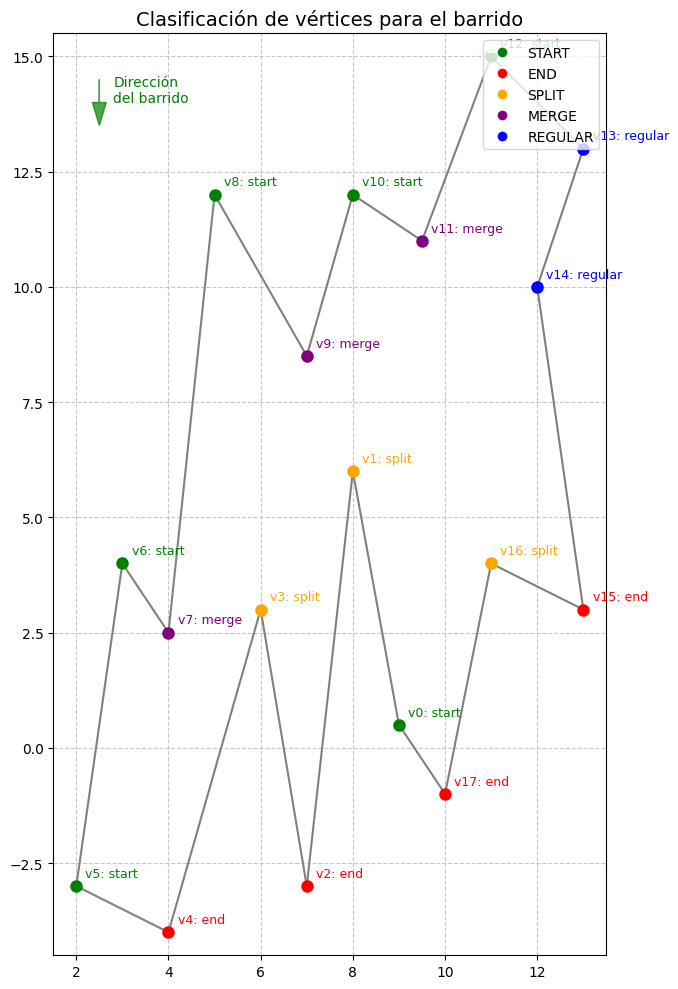


🧮 Verificación de regla para polígonos simples:
   START(6) + SPLIT(3) = END(4) + MERGE(3) + 2
   9 = 9
✅ La clasificación satisface la regla esperada

🚀 Procesando eventos paso a paso...

🔹 Evento 1/18: Vértice 12 (START)
📍 START → Insertar borde descendente desde V(11.0, 15.0)
➕ Insertada arista E(V(11.0, 15.0) → V(9.5, 11.0)) con helper V(8.0, 6.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(8.0, 6.0)


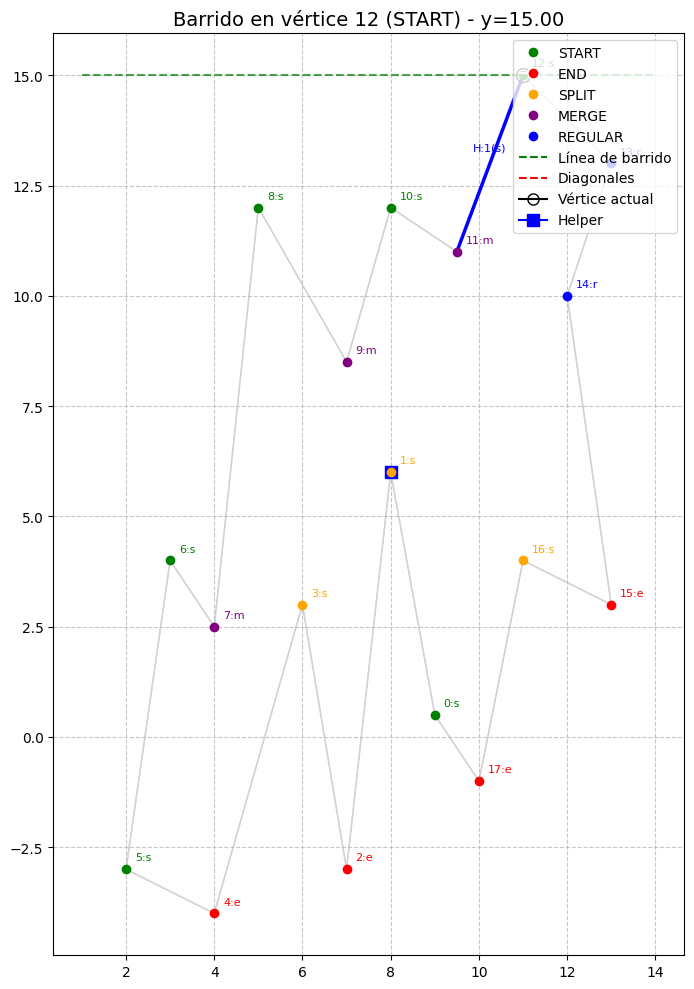


🔹 Evento 2/18: Vértice 13 (REGULAR)

📍 DIAGNÓSTICO REGULAR → Vértice V(13.0, 13.0) (Índice: 13)
↖ REGULAR como END (Interior a la izquierda)
  ✓ Arista incidente identificada: E(V(12.0, 10.0) → V(13.0, 13.0))
❌ No se encontró helper para E(V(12.0, 10.0) → V(13.0, 13.0))
❌ No se encontró helper para la arista incidente
⚠️ No se encontró la arista para eliminar: E(V(12.0, 10.0) → V(13.0, 13.0))

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(8.0, 6.0)


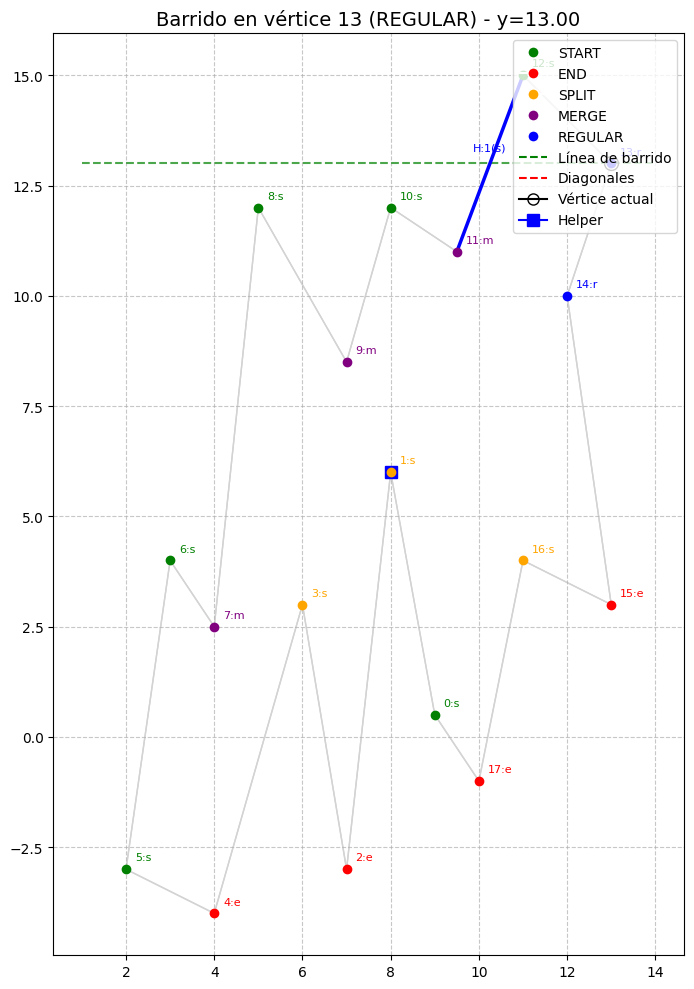


🔹 Evento 3/18: Vértice 8 (START)
📍 START → Insertar borde descendente desde V(5.0, 12.0)
➕ Insertada arista E(V(5.0, 12.0) → V(4.0, 2.5)) con helper V(8.0, 6.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(8.0, 6.0)
  02. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 6.0)


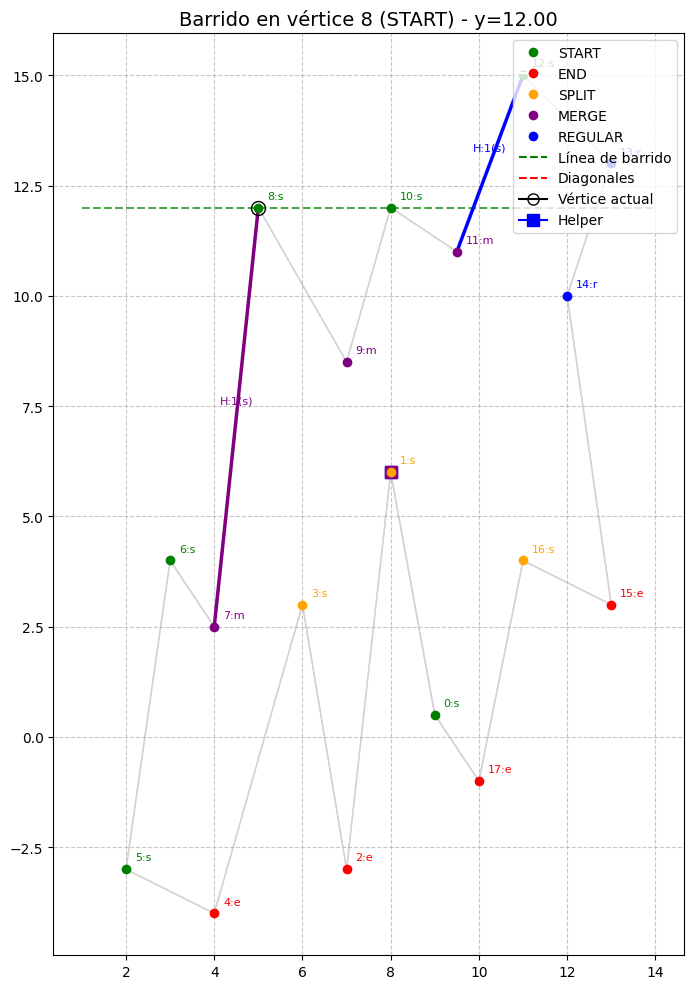


🔹 Evento 4/18: Vértice 10 (START)
📍 START → Insertar borde descendente desde V(8.0, 12.0)
➕ Insertada arista E(V(8.0, 12.0) → V(7.0, 8.5)) con helper V(8.0, 6.0)

📌 Estado actual del barrido:
  01. E(V(11.0, 15.0) → V(9.5, 11.0)) | Helper: V(8.0, 6.0)
  02. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 6.0)
  03. E(V(8.0, 12.0) → V(7.0, 8.5)) | Helper: V(8.0, 6.0)


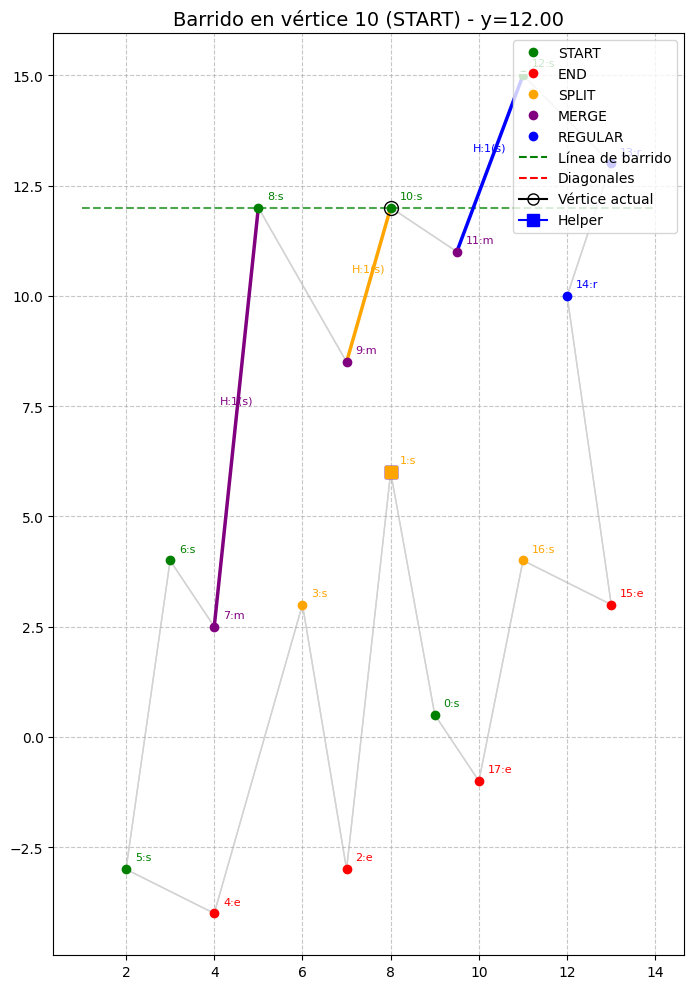


🔹 Evento 5/18: Vértice 11 (MERGE)

📍 MERGE → Procesar vértice V(9.5, 11.0)
  ✓ Arista E(V(5.0, 12.0) → V(4.0, 2.5)) intersecta y=11.0: (12.0 - 11.0) * (2.5 - 11.0) <= 0
  → Intersección de E(V(5.0, 12.0) → V(4.0, 2.5)) con y=11.0 es x=4.894736842105263
  ✓ Arista E(V(8.0, 12.0) → V(7.0, 8.5)) intersecta y=11.0: (12.0 - 11.0) * (8.5 - 11.0) <= 0
  → Intersección de E(V(8.0, 12.0) → V(7.0, 8.5)) con y=11.0 es x=7.714285714285714
  ✓ Arista incidente encontrada: E(V(11.0, 15.0) → V(9.5, 11.0))
  ✓ Helper: V(8.0, 6.0) (tipo: split)
✅ Diagonal válida entre V(9.5, 11.0) y V(8.0, 6.0)
➕ Insertando diagonal entre vértices 11 y 1
✅ Diagonal insertada: V(9.5, 11.0) ↔ V(8.0, 6.0)
➖ Eliminada arista E(V(11.0, 15.0) → V(9.5, 11.0))

📌 Estado actual del barrido:
  01. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 6.0)
  02. E(V(8.0, 12.0) → V(7.0, 8.5)) | Helper: V(8.0, 6.0)


C:\Users\juanh\AppData\Local\Temp\ipykernel_7672\767769966.py:111: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([v1.x, v2.x], [v1.y, v2.y], 'r-', linewidth=1.5, zorder=3, linestyle='--')


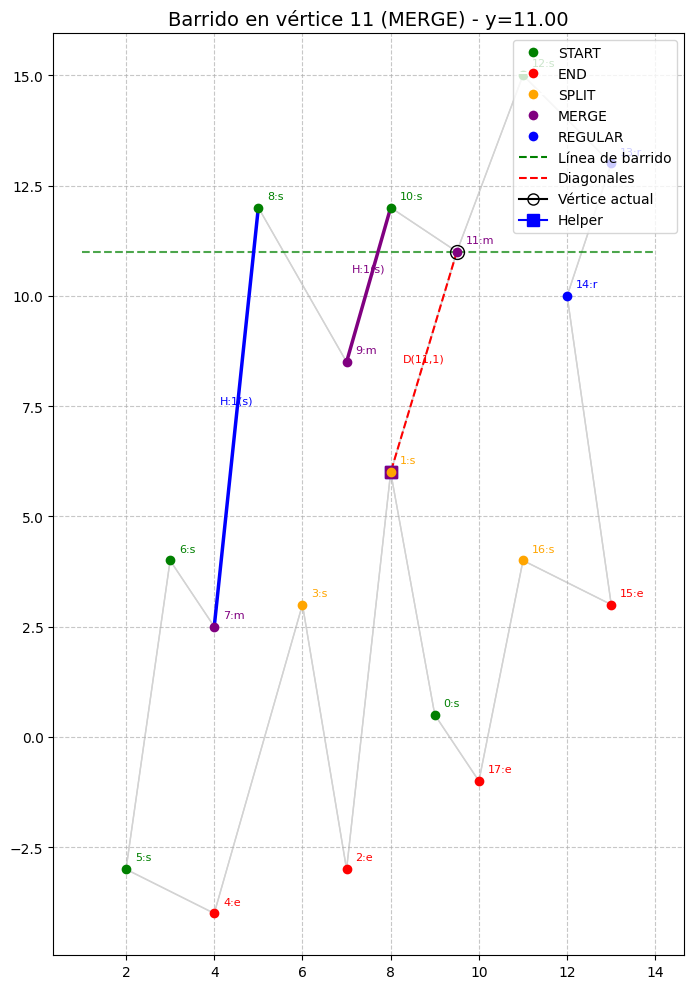


🔹 Evento 6/18: Vértice 14 (REGULAR)

📍 DIAGNÓSTICO REGULAR → Vértice V(12.0, 10.0) (Índice: 14)
↖ REGULAR como END (Interior a la izquierda)
  ✓ Arista incidente identificada: E(V(13.0, 3.0) → V(12.0, 10.0))
❌ No se encontró helper para E(V(13.0, 3.0) → V(12.0, 10.0))
❌ No se encontró helper para la arista incidente
⚠️ No se encontró la arista para eliminar: E(V(13.0, 3.0) → V(12.0, 10.0))

📌 Estado actual del barrido:
  01. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 6.0)
  02. E(V(8.0, 12.0) → V(7.0, 8.5)) | Helper: V(8.0, 6.0)


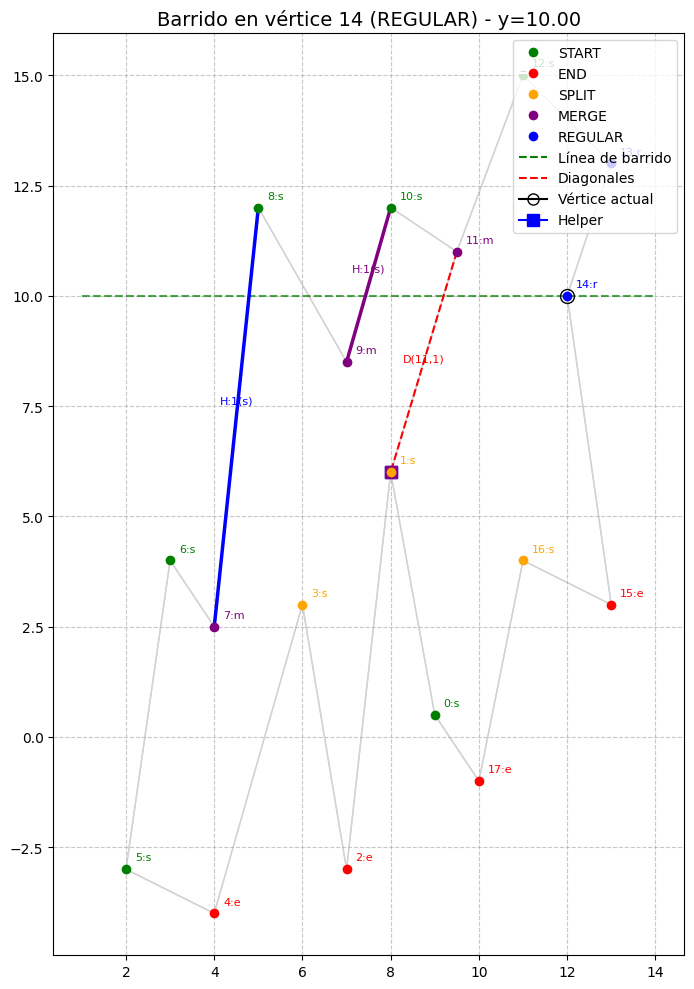


🔹 Evento 7/18: Vértice 9 (MERGE)

📍 MERGE → Procesar vértice V(7.0, 8.5)
  ✓ Arista E(V(5.0, 12.0) → V(4.0, 2.5)) intersecta y=8.5: (12.0 - 8.5) * (2.5 - 8.5) <= 0
  → Intersección de E(V(5.0, 12.0) → V(4.0, 2.5)) con y=8.5 es x=4.631578947368421
  ✓ Arista incidente encontrada: E(V(8.0, 12.0) → V(7.0, 8.5))
  ✓ Helper: V(8.0, 6.0) (tipo: split)
✅ Diagonal válida entre V(7.0, 8.5) y V(8.0, 6.0)
➕ Insertando diagonal entre vértices 9 y 1
✅ Diagonal insertada: V(7.0, 8.5) ↔ V(8.0, 6.0)
➖ Eliminada arista E(V(8.0, 12.0) → V(7.0, 8.5))

📌 Estado actual del barrido:
  01. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(8.0, 6.0)

🔹 Evento 8/18: Vértice 1 (SPLIT)

📍 SPLIT → Procesar vértice V(8.0, 6.0)
🔍 Buscando arista a la izquierda de (8.0, 6.0)...
   Total de aristas activas: 1
  ✓ Arista E(V(5.0, 12.0) → V(4.0, 2.5)) intersecta y=6.0: (12.0 - 6.0) * (2.5 - 6.0) <= 0
  → Intersección de E(V(5.0, 12.0) → V(4.0, 2.5)) con y=6.0 es x=4.368421052631579
   ✓ Candidata: E(V(5.0, 12.0) → V(4.0, 2.5)

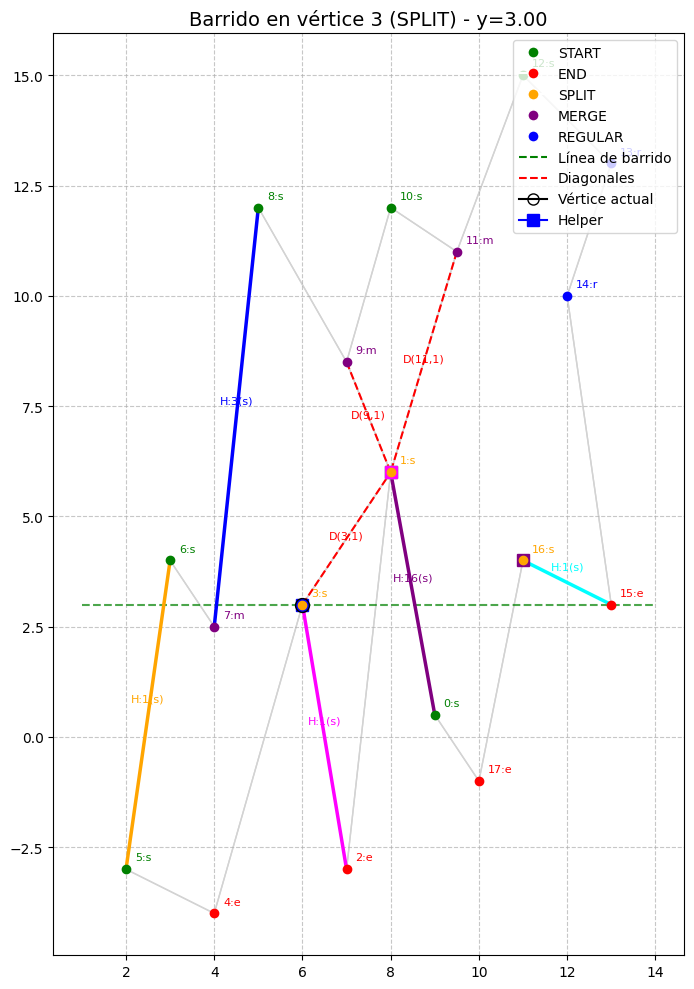


🔹 Evento 12/18: Vértice 15 (END)

📍 DIAGNÓSTICO END → Vértice V(13.0, 3.0) (Índice: 15)
  ✓ Arista incidente encontrada: E(V(11.0, 4.0) → V(13.0, 3.0))
  ✓ Helper: V(8.0, 6.0) (Índice: 1, Tipo: split)
➕ Helper tipo SPLIT - Candidata a diagonal: V(13.0, 3.0) ↔ V(8.0, 6.0)
✅ Diagonal válida entre V(13.0, 3.0) y V(8.0, 6.0)
➕ Insertando diagonal entre vértices 15 y 1
✅ Diagonal insertada: V(13.0, 3.0) ↔ V(8.0, 6.0)
✅ ÉXITO: Diagonal insertada V(13.0, 3.0) ↔ V(8.0, 6.0)
➖ Eliminada arista E(V(11.0, 4.0) → V(13.0, 3.0))

📌 Estado actual del barrido:
  01. E(V(5.0, 12.0) → V(4.0, 2.5)) | Helper: V(6.0, 3.0)
  02. E(V(8.0, 6.0) → V(9.0, 0.5)) | Helper: V(11.0, 4.0)
  03. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(8.0, 6.0)
  04. E(V(6.0, 3.0) → V(7.0, -3.0)) | Helper: V(8.0, 6.0)

🔹 Evento 13/18: Vértice 7 (MERGE)

📍 MERGE → Procesar vértice V(4.0, 2.5)
  ✓ Arista E(V(8.0, 6.0) → V(9.0, 0.5)) intersecta y=2.5: (6.0 - 2.5) * (0.5 - 2.5) <= 0
  → Intersección de E(V(8.0, 6.0) → V(9.0, 0.5)) con

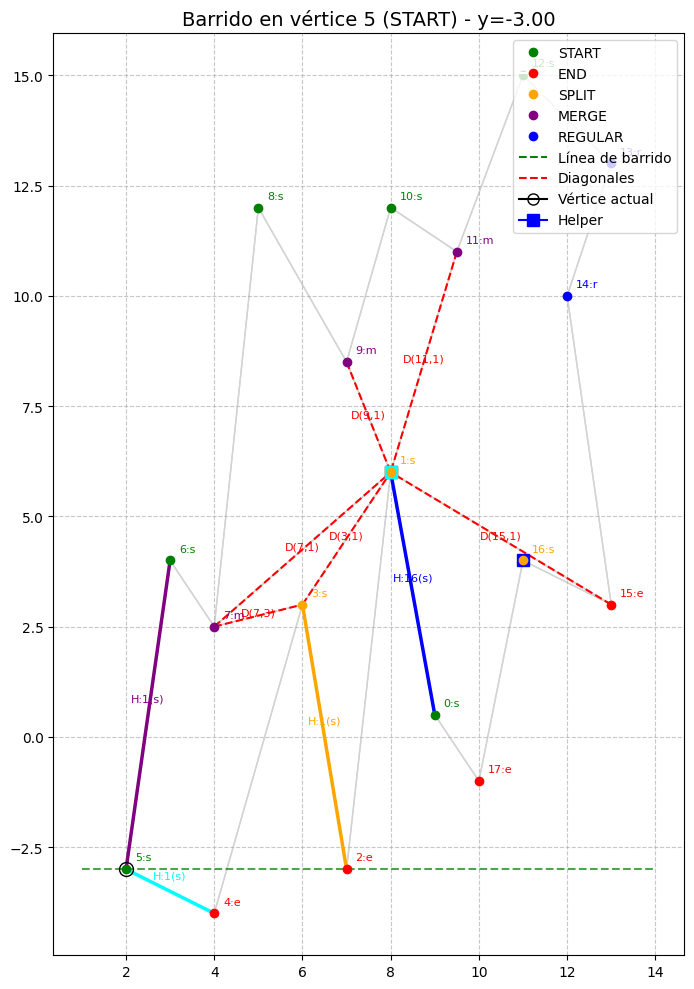


🔹 Evento 17/18: Vértice 2 (END)

📍 DIAGNÓSTICO END → Vértice V(7.0, -3.0) (Índice: 2)
  ✓ Arista incidente encontrada: E(V(6.0, 3.0) → V(7.0, -3.0))
  ✓ Helper: V(8.0, 6.0) (Índice: 1, Tipo: split)
➕ Helper tipo SPLIT - Candidata a diagonal: V(7.0, -3.0) ↔ V(8.0, 6.0)
❌ Los vértices 2 y 1 están demasiado cerca
❌ La diagonal no es válida
➖ Eliminada arista E(V(6.0, 3.0) → V(7.0, -3.0))

📌 Estado actual del barrido:
  01. E(V(8.0, 6.0) → V(9.0, 0.5)) | Helper: V(11.0, 4.0)
  02. E(V(3.0, 4.0) → V(2.0, -3.0)) | Helper: V(8.0, 6.0)
  03. E(V(2.0, -3.0) → V(4.0, -4.0)) | Helper: V(8.0, 6.0)

🔹 Evento 18/18: Vértice 4 (END)

📍 DIAGNÓSTICO END → Vértice V(4.0, -4.0) (Índice: 4)
  ✓ Arista incidente encontrada: E(V(2.0, -3.0) → V(4.0, -4.0))
  ✓ Helper: V(8.0, 6.0) (Índice: 1, Tipo: split)
➕ Helper tipo SPLIT - Candidata a diagonal: V(4.0, -4.0) ↔ V(8.0, 6.0)
❌ El punto medio está fuera del polígono
❌ La diagonal no es válida
➖ Eliminada arista E(V(2.0, -3.0) → V(4.0, -4.0))

📌 Estado actual 

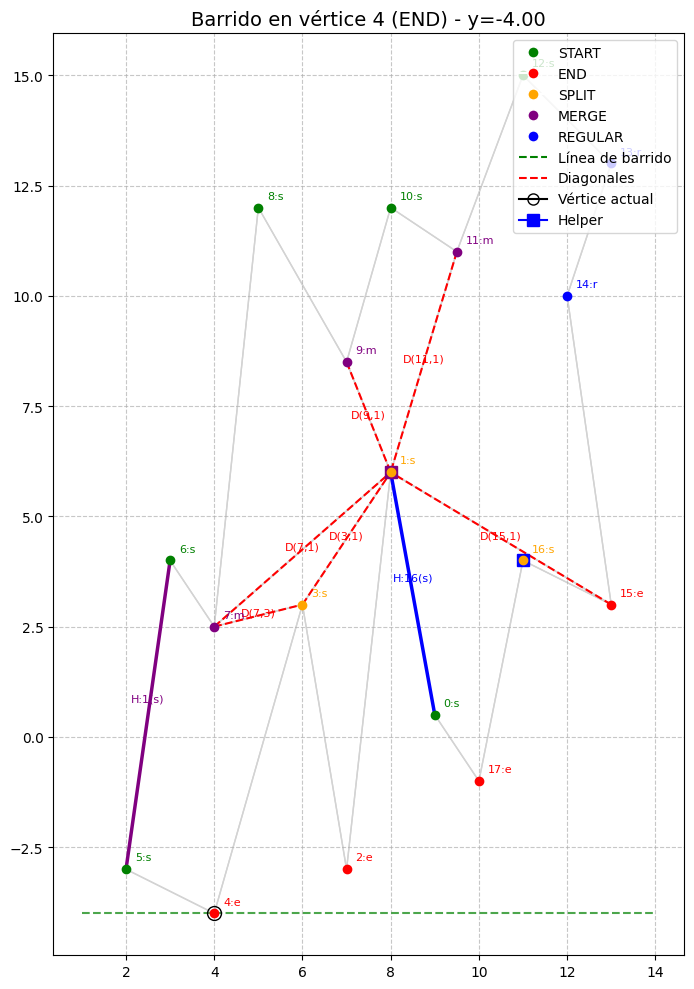


📊 Visualizando resultado final...


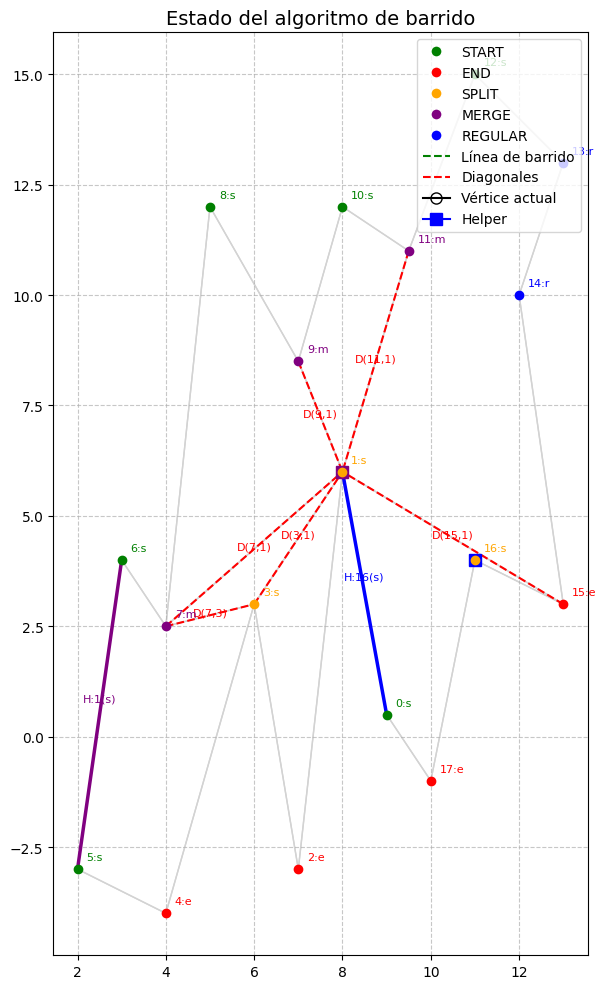

[(Vertex(9.5, 11.0), Vertex(8.0, 6.0)), (Vertex(7.0, 8.5), Vertex(8.0, 6.0)), (Vertex(6.0, 3.0), Vertex(8.0, 6.0)), (Vertex(13.0, 3.0), Vertex(8.0, 6.0)), (Vertex(4.0, 2.5), Vertex(8.0, 6.0)), (Vertex(4.0, 2.5), Vertex(6.0, 3.0))]


In [225]:
def probar_algoritmo_barrido():
    """
    Ejecuta una prueba completa del algoritmo de barrido.
    """
    print("\n" + "="*60)
    print("PRUEBA DEL ALGORITMO DE BARRIDO")
    print("="*60)
    
    try:
        # 1. Cargar puntos y construir DCEL
        print("\n📂 Cargando puntos y construyendo DCEL...")
        puntos = cargar_puntos("Polygon.txt")
        dcel = construir_dcel_simple(puntos)
        
        # 2. Verificar integridad del DCEL
        resultado = verificar_integridad_dcel(dcel, verbose=False, invertir_convencion=True)
        if not resultado["estatus_global"]:
            print("❌ El DCEL tiene problemas estructurales. Abortando.")
            return None
        
        # 3. Clasificar vértices
        print("\n🔍 Clasificando vértices...")
        clasificacion = clasificar_vertices_dcel(dcel, debug=True)
        
        # 4. Preparar eventos
        print("\n📋 Preparando eventos...")
        eventos = preparar_eventos(dcel, clasificacion, debug=True)
        verificar_orden_eventos(eventos, debug=True)
        
        # 5. Visualizar estado inicial
        print("\n🔍 Visualizando estado inicial...")
        visualizar_clasificacion(dcel, clasificacion, "Clasificación de vértices para el barrido")
        
        # 6. Procesar eventos paso a paso con visualización
        print("\n🚀 Procesando eventos paso a paso...")
        estado = EstadoBarridoSimple()
        diagonales = []
        
        # Procesa algunos eventos específicos para visualización
        eventos_a_mostrar = [0, 1, 2, 3, 4, 5, 10, 15]  # Índices de eventos a visualizar
        
        for i, (v, tipo) in enumerate(eventos):
            print(f"\n{'='*60}")
            print(f"🔹 Evento {i+1}/{len(eventos)}: Vértice {dcel.vertices.index(v)} ({tipo.upper()})")
            print(f"{'='*60}")
            
            # Procesar según el tipo de evento
            tipo_lower = tipo.lower()
            
            # CAMBIO: Añadir explícitamente el parámetro debug=True a todas las llamadas
            if tipo_lower == "start":
                handle_start_vertex(v, dcel, estado, clasificacion, debug=True)
            elif tipo_lower == "end":
                handle_end_vertex(v, dcel, estado, clasificacion, diagonales, debug=True)
            elif tipo_lower == "merge":
                handle_merge_vertex(v, dcel, estado, clasificacion, diagonales, debug=True)
            elif tipo_lower == "split":
                handle_split_vertex(v, dcel, estado, clasificacion, diagonales, debug=True)
            elif tipo_lower == "regular":
                handle_regular_vertex(v, dcel, estado, clasificacion, diagonales, debug=True)
            
            print(estado)
            
            #Visualizar solo algunos eventos para no saturar
            if i in eventos_a_mostrar:
                visualizar_estado_barrido(dcel, v, estado, diagonales, clasificacion)
            #     input("Presiona Enter para continuar...")
            
            if i == len(eventos) - 1:  # Último evento
                visualizar_estado_barrido(dcel, v, estado, diagonales, clasificacion)
        
        # print("\n✅ Procesamiento de eventos completado")
        # print(f"   Total de diagonales insertadas: {len(diagonales)}")
        
        # 7. Visualizar resultado final
        print("\n📊 Visualizando resultado final...")
        visualizar_estado_barrido(dcel, None, estado, diagonales, clasificacion)
        
        return diagonales, dcel
        
    except Exception as e:
        print(f"\n❌ Error durante la prueba: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# Ejecutar la prueba
diagonales, dcel = probar_algoritmo_barrido()

print (diagonales)



In [223]:
def extraer_poligonos_monotonos(dcel, diagonales, debug=False):
    """
    Extrae los polígonos y-monótonos a partir de la DCEL y las diagonales insertadas.
    
    Parámetros:
    - dcel: La estructura DCEL
    - diagonales: Lista de tuplas de vértices (v1, v2) que representan las diagonales
    - debug: Si True, muestra información detallada
    
    Retorna:
    - Lista de polígonos y-monótonos, cada uno como una lista ordenada de vértices
    """
    if debug:
        print("Extrayendo polígonos y-monótonos...")
    
    # Construir un grafo para representar el polígono con diagonales
    grafo = {}
    for v in dcel.vertices:
        grafo[v] = []
    
    # Añadir aristas del polígono original
    for i, v in enumerate(dcel.vertices):
        grafo[v].append(dcel.vertices[(i+1) % len(dcel.vertices)])
        grafo[dcel.vertices[(i+1) % len(dcel.vertices)]].append(v)
    
    # Añadir diagonales
    for v1, v2 in diagonales:
        grafo[v1].append(v2)
        grafo[v2].append(v1)
    
    # Encontrar todas las caras (polígonos) usando un algoritmo de recorrido de caras
    poligonos = []
    aristas_visitadas = set()
    
    def siguiente_arista_ccw(v, vecino_actual, vecinos):
        # Ordenar vecinos en sentido antihorario respecto a v
        vecinos_ordenados = sorted(vecinos, key=lambda vecino: 
                                   math.atan2(vecino.y - v.y, vecino.x - v.x))
        
        # Encontrar la posición del vecino actual
        try:
            pos = vecinos_ordenados.index(vecino_actual)
            # Retornar el siguiente vecino en sentido antihorario
            return vecinos_ordenados[(pos + 1) % len(vecinos_ordenados)]
        except ValueError:
            # Si el vecino_actual no está en la lista (no debería ocurrir)
            return vecinos_ordenados[0]
    
    # Para cada arista no visitada, recorrer la cara
    for v in dcel.vertices:
        for vecino in grafo[v]:
            # Crear un identificador único para la arista
            arista = (min(v, vecino, key=lambda x: id(x)), 
                      max(v, vecino, key=lambda x: id(x)))
            
            # Si ya visitamos esta arista, continuamos
            if arista in aristas_visitadas:
                continue
            
            # Recorrer la cara en sentido antihorario
            poligono = []
            v_actual = v
            v_siguiente = vecino
            
            while True:
                poligono.append(v_actual)
                aristas_visitadas.add((min(v_actual, v_siguiente, key=lambda x: id(x)),
                                     max(v_actual, v_siguiente, key=lambda x: id(x))))
                
                # Avanzar al siguiente vértice
                v_temp = v_actual
                v_actual = v_siguiente
                v_siguiente = siguiente_arista_ccw(v_actual, v_temp, grafo[v_actual])
                
                # Si completamos el ciclo, terminamos
                if v_actual == v and v_siguiente == vecino:
                    break
            
            # Añadir el polígono a la lista
            poligonos.append(poligono)
    
    # Verificar que cada polígono es y-monótono
    poligonos_monotonos = []
    for p in poligonos:
        if es_poligono_y_monotono(p):
            poligonos_monotonos.append(p)
            if debug:
                print(f"Polígono y-monótono encontrado con {len(p)} vértices")
        else:
            if debug:
                print(f"Polígono no y-monótono con {len(p)} vértices")
    
    return poligonos_monotonos


def es_poligono_y_monotono(poligono):
    """
    Verifica si un polígono es y-monótono.
    Un polígono es y-monótono si se puede dividir en dos cadenas monótonas en y.
    
    Parámetros:
    - poligono: Lista de vértices del polígono
    
    Retorna:
    - True si el polígono es y-monótono, False en caso contrario
    """
    # Encontrar vértice con mayor y (punto más alto)
    idx_max_y = max(range(len(poligono)), key=lambda i: poligono[i].y)
    # Encontrar vértice con menor y (punto más bajo)
    idx_min_y = min(range(len(poligono)), key=lambda i: poligono[i].y)
    
    # Crear las dos cadenas: izquierda y derecha
    n = len(poligono)
    cadena_izq = []
    cadena_der = []
    
    # Construir cadena izquierda (desde máximo Y hasta mínimo Y)
    i = idx_max_y
    while i != idx_min_y:
        cadena_izq.append(poligono[i])
        i = (i + 1) % n
    cadena_izq.append(poligono[idx_min_y])
    
    # Construir cadena derecha (desde máximo Y hasta mínimo Y)
    i = idx_max_y
    while i != idx_min_y:
        cadena_der.append(poligono[i])
        i = (i - 1) % n
    cadena_der.append(poligono[idx_min_y])
    
    # Verificar monotonía de ambas cadenas
    for cadena in [cadena_izq, cadena_der]:
        for i in range(1, len(cadena)):
            if cadena[i].y > cadena[i-1].y:
                return False
    
    return True

In [224]:
def triangular_poligono_monotono(poligono, debug=False):
    """
    Triangula un polígono y-monótono usando un algoritmo lineal.
    
    Parámetros:
    - poligono: Lista de vértices del polígono y-monótono
    - debug: Si True, muestra información detallada
    
    Retorna:
    - Lista de tuplas (v1, v2, v3) que representan los triángulos
    """
    if debug:
        print(f"Triangulando polígono y-monótono con {len(poligono)} vértices...")
    
    # Ordenar vértices por coordenada y (descendente)
    vertices_ordenados = sorted(poligono, key=lambda v: v.y, reverse=True)
    
    # Identificar las cadenas izquierda y derecha
    v_top = vertices_ordenados[0]  # Vértice superior
    v_bottom = vertices_ordenados[-1]  # Vértice inferior
    
    # Determinar qué vértices pertenecen a qué cadena
    cadena_izq = []
    cadena_der = []
    
    # Construir las cadenas
    v_actual = v_top
    idx_actual = poligono.index(v_actual)
    n = len(poligono)
    
    # Recorrer en sentido horario para encontrar una cadena
    idx_next = (idx_actual + 1) % n
    v_next = poligono[idx_next]
    
    while v_next != v_bottom:
        cadena_der.append(v_next)
        idx_actual = idx_next
        idx_next = (idx_actual + 1) % n
        v_next = poligono[idx_next]
    
    # Recorrer en sentido antihorario para encontrar la otra cadena
    idx_actual = poligono.index(v_top)
    idx_next = (idx_actual - 1) % n
    v_next = poligono[idx_next]
    
    while v_next != v_bottom:
        cadena_izq.append(v_next)
        idx_actual = idx_next
        idx_next = (idx_actual - 1) % n
        v_next = poligono[idx_next]
    
    # Marcar cada vértice según la cadena a la que pertenece
    es_izquierda = {}
    for v in poligono:
        es_izquierda[v] = v in cadena_izq
    
    # Pila para el algoritmo de triangulación
    pila = [vertices_ordenados[0], vertices_ordenados[1]]
    
    # Triángulos resultantes
    triangulos = []
    
    # Procesar vértices en orden descendente de y
    for i in range(2, len(vertices_ordenados) - 1):
        v = vertices_ordenados[i]
        
        # Verificar si v está en cadena opuesta al tope de la pila
        if es_izquierda[v] != es_izquierda[pila[-1]]:
            # Crear triángulos con todos los vértices en la pila excepto el primero
            while len(pila) > 1:
                triangulos.append((v, pila[-1], pila[-2]))
                pila.pop()
            
            # Reiniciar pila
            pila = [pila[0], v]
        else:
            # v está en la misma cadena que el tope de la pila
            ultimo = pila.pop()
            
            # Crear triángulos mientras se pueda
            while pila:
                if (es_izquierda[v] and es_diagonal_valida(pila[-1], v, poligono)) or \
                   (not es_izquierda[v] and es_diagonal_valida(v, pila[-1], poligono)):
                    triangulos.append((v, ultimo, pila[-1]))
                    ultimo = pila.pop()
                else:
                    break
            
            # Actualizar pila
            pila.append(ultimo)
            pila.append(v)
    
    # Procesar el último vértice
    v = vertices_ordenados[-1]
    
    # Triangular con todos los vértices restantes en la pila
    while len(pila) > 1:
        triangulos.append((v, pila[-1], pila[-2]))
        pila.pop()
    
    if debug:
        print(f"Triangulación completa: {len(triangulos)} triángulos generados")
    
    return triangulos


def es_diagonal_valida(v1, v2, poligono):
    """
    Verifica si una diagonal entre v1 y v2 es válida dentro del polígono.
    
    Parámetros:
    - v1, v2: Vértices extremos de la diagonal
    - poligono: Lista de vértices del polígono
    
    Retorna:
    - True si la diagonal es válida, False en caso contrario
    """
    n = len(poligono)
    idx1 = poligono.index(v1)
    idx2 = poligono.index(v2)
    
    # Verificar si v1 y v2 son adyacentes
    if abs(idx1 - idx2) == 1 or abs(idx1 - idx2) == n - 1:
        return False
    
    # Verificar si la diagonal está dentro del polígono
    # Para polígonos y-monótonos, esto generalmente no es necesario verificarlo
    # porque el algoritmo garantiza diagonales válidas, pero lo incluimos por completitud
    
    # Punto medio de la diagonal
    mid_x = (v1.x + v2.x) / 2
    mid_y = (v1.y + v2.y) / 2
    
    # Verificar si el punto medio está dentro del polígono
    return punto_en_poligono((mid_x, mid_y), [(v.x, v.y) for v in poligono])

# Punto 3 triangulación

In [226]:
def insertar_triangulacion_en_dcel(dcel, triangulos, debug=False):
    """
    Inserta las diagonales de la triangulación en la estructura DCEL.
    
    Parámetros:
    - dcel: La estructura DCEL
    - triangulos: Lista de tuplas (v1, v2, v3) que representan los triángulos
    - debug: Si True, muestra información detallada
    
    Retorna:
    - DCEL actualizada con las diagonales
    """
    if debug:
        print(f"Insertando {len(triangulos)} triángulos en la DCEL...")
    
    # Extraer todas las diagonales de los triángulos
    diagonales = set()
    for v1, v2, v3 in triangulos:
        # Verificar que las aristas no sean del borde original
        # Esto requiere verificar adyacencia en el polígono original
        for a, b in [(v1, v2), (v2, v3), (v3, v1)]:
            idx_a = dcel.vertices.index(a)
            idx_b = dcel.vertices.index(b)
            n = len(dcel.vertices)
            
            # Si no son adyacentes en el polígono original, es una diagonal
            if not (abs(idx_a - idx_b) == 1 or abs(idx_a - idx_b) == n - 1):
                # Ordenar vértices para evitar duplicados
                diagonal = tuple(sorted([a, b], key=lambda v: id(v)))
                diagonales.add(diagonal)
    
    # Insertar cada diagonal en la DCEL
    nuevas_diagonales = []
    for v1, v2 in diagonales:
        # Verificar si la diagonal ya existe
        existe = False
        for e in dcel.edges:
            if (e.origin == v1 and e.twin.origin == v2) or \
               (e.origin == v2 and e.twin.origin == v1):
                existe = True
                break
        
        if not existe:
            if debug:
                print(f"Insertando diagonal entre vértices {dcel.vertices.index(v1)} y {dcel.vertices.index(v2)}")
            
            # Crear la diagonal
            e1, e2 = dcel.add_edge(v1, v2)
            nuevas_diagonales.append((v1, v2))
    
    if debug:
        print(f"Insertadas {len(nuevas_diagonales)} nuevas diagonales en la DCEL")
    
    return dcel, nuevas_diagonales

In [227]:
def visualizar_triangulacion(dcel, diagonales, titulo="Polígono Triangulado"):
    """
    Visualiza el polígono con su triangulación.
    
    Parámetros:
    - dcel: La estructura DCEL
    - diagonales: Lista de tuplas (v1, v2) que representan las diagonales
    - titulo: Título del gráfico
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Dibujar el polígono original
    x = [v.x for v in dcel.vertices]
    y = [v.y for v in dcel.vertices]
    x.append(dcel.vertices[0].x)
    y.append(dcel.vertices[0].y)
    
    # Rellenar el polígono con un color claro
    ax.fill(x, y, alpha=0.2, facecolor='skyblue')
    
    # Dibujar el borde del polígono
    ax.plot(x, y, 'b-', linewidth=1.5)
    
    # Dibujar las diagonales
    for v1, v2 in diagonales:
        ax.plot([v1.x, v2.x], [v1.y, v2.y], 'r--', linewidth=1.2)
    
    # Dibujar los vértices
    ax.scatter([v.x for v in dcel.vertices], [v.y for v in dcel.vertices], 
               color='blue', s=40, zorder=5)
    
    # Etiquetar los vértices
    for i, v in enumerate(dcel.vertices):
        ax.text(v.x + 0.1, v.y + 0.1, str(i), fontsize=8, ha='center')
    
    # Configuración del gráfico
    ax.set_aspect('equal')
    ax.set_title(titulo)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()


def visualizar_triangulos(dcel, triangulos, titulo="Triángulos de la Triangulación"):
    """
    Visualiza los triángulos resultantes de la triangulación.
    
    Parámetros:
    - dcel: La estructura DCEL
    - triangulos: Lista de tuplas (v1, v2, v3) que representan los triángulos
    - titulo: Título del gráfico
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Dibujar el polígono original (contorno)
    x = [v.x for v in dcel.vertices]
    y = [v.y for v in dcel.vertices]
    x.append(dcel.vertices[0].x)
    y.append(dcel.vertices[0].y)
    ax.plot(x, y, 'b-', linewidth=1, alpha=0.5)
    
    # Colores para los triángulos
    colors = plt.cm.tab20(np.linspace(0, 1, len(triangulos)))
    
    # Dibujar cada triángulo con un color distinto
    for i, (v1, v2, v3) in enumerate(triangulos):
        ax.fill([v1.x, v2.x, v3.x], [v1.y, v2.y, v3.y], 
                alpha=0.4, facecolor=colors[i % len(colors)])
        
        # Dibujar los bordes de los triángulos
        ax.plot([v1.x, v2.x, v3.x, v1.x], [v1.y, v2.y, v3.y, v1.y], 
                'k-', linewidth=0.5)
        
        # Añadir etiqueta al centro del triángulo
        centro_x = (v1.x + v2.x + v3.x) / 3
        centro_y = (v1.y + v2.y + v3.y) / 3
        ax.text(centro_x, centro_y, str(i), fontsize=8, ha='center')
    
    # Dibujar los vértices del polígono
    ax.scatter([v.x for v in dcel.vertices], [v.y for v in dcel.vertices], 
               color='blue', s=30, zorder=5)
    
    # Etiquetar los vértices
    for i, v in enumerate(dcel.vertices):
        ax.text(v.x + 0.1, v.y + 0.1, str(i), fontsize=8, ha='center')
    
    # Configuración del gráfico
    ax.set_aspect('equal')
    ax.set_title(titulo)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [228]:
def triangular_poligonos_y_monotonos(dcel, diagonales_barrido, debug=True):
    """
    Función principal para triangular todos los polígonos y-monótonos.
    
    Parámetros:
    - dcel: La estructura DCEL original
    - diagonales_barrido: Diagonales resultantes del algoritmo de barrido
    - debug: Si True, muestra información detallada
    
    Retorna:
    - DCEL actualizada con todas las diagonales
    - Lista de todos los triángulos
    """
    if debug:
        print("\n" + "="*60)
        print("TRIANGULACIÓN DE POLÍGONOS Y-MONÓTONOS")
        print("="*60)
    
    # 1. Extraer los polígonos y-monótonos
    poligonos = extraer_poligonos_monotonos(dcel, diagonales_barrido, debug)
    
    if debug:
        print(f"\nSe encontraron {len(poligonos)} polígonos y-monótonos")
    
    # 2. Triangular cada polígono y-monótono
    todos_triangulos = []
    for i, poligono in enumerate(poligonos):
        if debug:
            print(f"\nTriangulando polígono y-monótono #{i+1}...")
        
        triangulos = triangular_poligono_monotono(poligono, debug)
        todos_triangulos.extend(triangulos)
        
        if debug:
            print(f"Generados {len(triangulos)} triángulos")
    
    # 3. Actualizar la DCEL con todas las diagonales
    dcel_final, nuevas_diagonales = insertar_triangulacion_en_dcel(dcel, todos_triangulos, debug)
    
    # 4. Combinar las diagonales del barrido con las nuevas
    todas_diagonales = diagonales_barrido + nuevas_diagonales
    
    if debug:
        print("\n" + "="*60)
        print(f"Triangulación completa: {len(todos_triangulos)} triángulos")
        print(f"Total de diagonales: {len(todas_diagonales)}")
        print("="*60)
    
    # 5. Visualizar el resultado
    visualizar_triangulacion(dcel_final, todas_diagonales, "Polígono con Triangulación Completa")
    visualizar_triangulos(dcel_final, todos_triangulos, "Triángulos Resultantes")
    
    return dcel_final, todos_triangulos, todas_diagonales


TRIANGULACIÓN DE POLÍGONOS Y-MONÓTONOS
Extrayendo polígonos y-monótonos...
Polígono no y-monótono con 5 vértices
Polígono y-monótono encontrado con 3 vértices
Polígono y-monótono encontrado con 6 vértices
Polígono y-monótono encontrado con 4 vértices
Polígono y-monótono encontrado con 4 vértices
Polígono no y-monótono con 5 vértices

Se encontraron 4 polígonos y-monótonos

Triangulando polígono y-monótono #1...
Triangulando polígono y-monótono con 3 vértices...
Triangulación completa: 1 triángulos generados
Generados 1 triángulos

Triangulando polígono y-monótono #2...
Triangulando polígono y-monótono con 6 vértices...
Triangulación completa: 4 triángulos generados
Generados 4 triángulos

Triangulando polígono y-monótono #3...
Triangulando polígono y-monótono con 4 vértices...
Triangulación completa: 2 triángulos generados
Generados 2 triángulos

Triangulando polígono y-monótono #4...
Triangulando polígono y-monótono con 4 vértices...
Triangulación completa: 2 triángulos generados
Gen

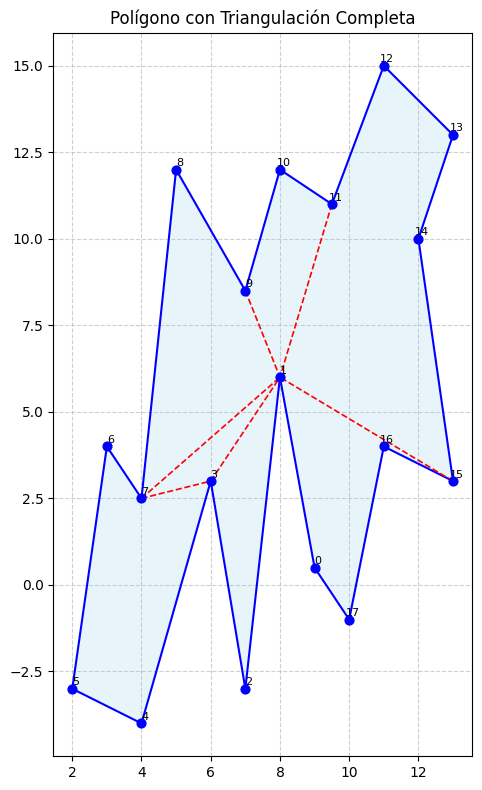

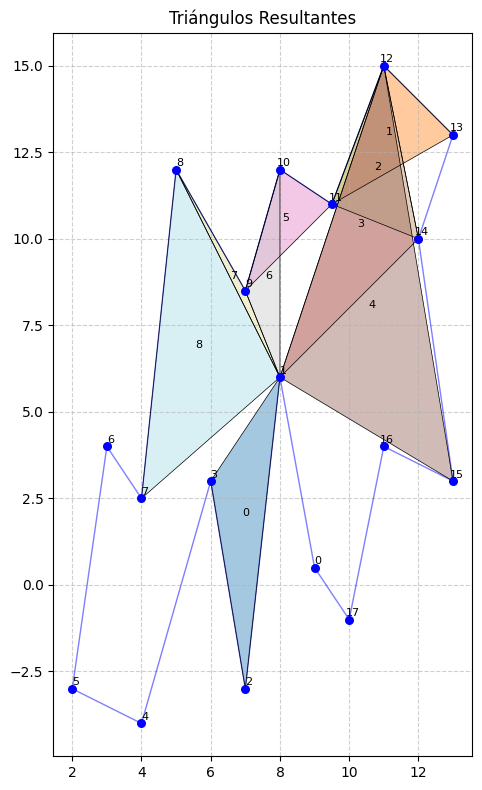

Triangulación completa: 9 triángulos
Total de diagonales: 6
DCEL[(Vertex(7.0, -3.0), Vertex(6.0, 3.0), Vertex(8.0, 6.0)), (Vertex(9.5, 11.0), Vertex(13.0, 13.0), Vertex(11.0, 15.0)), (Vertex(12.0, 10.0), Vertex(9.5, 11.0), Vertex(11.0, 15.0)), (Vertex(8.0, 6.0), Vertex(12.0, 10.0), Vertex(11.0, 15.0)), (Vertex(13.0, 3.0), Vertex(8.0, 6.0), Vertex(11.0, 15.0)), (Vertex(7.0, 8.5), Vertex(9.5, 11.0), Vertex(8.0, 12.0)), (Vertex(8.0, 6.0), Vertex(7.0, 8.5), Vertex(8.0, 12.0)), (Vertex(8.0, 6.0), Vertex(7.0, 8.5), Vertex(5.0, 12.0)), (Vertex(4.0, 2.5), Vertex(8.0, 6.0), Vertex(5.0, 12.0))] con 6 diagonales


In [231]:
# Asumiendo que ya tienes:
# - dcel: La estructura DCEL del polígono
# - diagonales: Las diagonales insertadas por el algoritmo de barrido

# Triangular todos los polígonos y-monótonos
dcel_triangulado, triangulos, todas_diagonales = triangular_poligonos_y_monotonos(dcel, diagonales)

print(f"Triangulación completa: {len(triangulos)} triángulos")
print(f"Total de diagonales: {len(todas_diagonales)}")
print(f"DCEL{triangulos} con {len(todas_diagonales)} diagonales")	

In [199]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as PlotPolygon

def colorear_vertices_triangulacion(dcel, triangulos, debug=False):
    """
    Aplica el algoritmo de 3-coloración a los vértices del polígono triangulado.
    """
    # Construir el grafo de adyacencia
    grafo = {v: set() for v in dcel.vertices}
    
    # Añadir aristas basadas en los triángulos
    for v1, v2, v3 in triangulos:
        grafo[v1].add(v2)
        grafo[v1].add(v3)
        grafo[v2].add(v1)
        grafo[v2].add(v3)
        grafo[v3].add(v1)
        grafo[v3].add(v2)
    
    # También añadir aristas del borde del polígono
    for i in range(len(dcel.vertices)):
        v1 = dcel.vertices[i]
        v2 = dcel.vertices[(i + 1) % len(dcel.vertices)]
        grafo[v1].add(v2)
        grafo[v2].add(v1)
    
    # Inicializar colores
    colores = {}
    vertices_ordenados = list(dcel.vertices)
    
    # Aplicar algoritmo de coloración voraz
    colores[vertices_ordenados[0]] = 0
    for v in vertices_ordenados[1:]:
        colores_usados = {colores.get(vecino) for vecino in grafo[v] 
                          if vecino in colores}
        for color in range(3):
            if color not in colores_usados:
                colores[v] = color
                break
    
    if debug:
        conteo = [0, 0, 0]
        for color in colores.values():
            conteo[color] += 1
        print(f"Distribución de colores: Rojo={conteo[0]}, Verde={conteo[1]}, Azul={conteo[2]}")
    
    return colores

def seleccionar_camaras(dcel, colores, debug=False):
    """
    Selecciona el conjunto mínimo de vértices para colocar cámaras.
    """
    # Contar vértices por color
    conteo = [0, 0, 0]
    vertices_por_color = [[], [], []]
    
    for v, color in colores.items():
        conteo[color] += 1
        vertices_por_color[color].append(v)
    
    # Seleccionar el color con menor número de vértices
    color_minimo = conteo.index(min(conteo))
    camaras = vertices_por_color[color_minimo]
    
    if debug:
        print(f"Color seleccionado: {['Rojo', 'Verde', 'Azul'][color_minimo]} con {conteo[color_minimo]} vértices")
        print(f"Índices de vértices para cámaras: {[dcel.vertices.index(v) for v in camaras]}")
    
    return camaras

def visualizar_camaras(dcel, triangulos, camaras, colores, titulo="Solución del Problema de la Galería de Arte"):
    """
    Visualiza el polígono con las cámaras seleccionadas.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Dibujar polígono original
    x = [v.x for v in dcel.vertices]
    y = [v.y for v in dcel.vertices]
    x.append(dcel.vertices[0].x)
    y.append(dcel.vertices[0].y)
    
    ax.fill(x, y, alpha=0.2, facecolor='skyblue')
    ax.plot(x, y, 'b-', linewidth=1.5)
    
    # Dibujar triangulación suavemente
    for t in triangulos:
        v1, v2, v3 = t
        for a, b in [(v1, v2), (v2, v3), (v3, v1)]:
            idx_a = dcel.vertices.index(a)
            idx_b = dcel.vertices.index(b)
            n = len(dcel.vertices)
            if not (abs(idx_a - idx_b) == 1 or abs(idx_a - idx_b) == n - 1):
                ax.plot([a.x, b.x], [a.y, b.y], 'r--', linewidth=0.5, alpha=0.3)
    
    # Dibujar vértices por color
    color_names = ['red', 'green', 'blue']
    for color in range(3):
        vertices = [v for v, c in colores.items() if c == color]
        ax.scatter([v.x for v in vertices], [v.y for v in vertices], 
                  color=color_names[color], s=50, zorder=5, 
                  label=f'Color {color+1}')
    
    # Destacar cámaras
    ax.scatter([v.x for v in camaras], [v.y for v in camaras], 
              color='gold', s=180, marker='*', edgecolor='black', 
              linewidth=1.5, zorder=6, label='Cámaras')
    
    # Visualizar área de vigilancia
    for v in camaras:
        # Dibujar líneas desde la cámara a todos los vértices visibles
        for w in dcel.vertices:
            if v != w:
                # Verificar visibilidad (simplificado para el ejemplo)
                ax.plot([v.x, w.x], [v.y, w.y], 'y-', linewidth=0.3, alpha=0.1, zorder=1)
    
    # Etiquetar vértices
    for i, v in enumerate(dcel.vertices):
        ax.text(v.x + 0.2, v.y + 0.2, str(i), fontsize=9, ha='center')
    
    ax.set_aspect('equal')
    ax.set_title(titulo)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

def resolver_problema_galeria_arte(dcel, triangulos, debug=True):
    """
    Resuelve el problema de la galería de arte (ubicación mínima de cámaras).
    """
    if debug:
        print("\n" + "="*60)
        print("RESOLUCIÓN DEL PROBLEMA DE LA GALERÍA DE ARTE")
        print("="*60)
        print(f"\nPolígono con {len(dcel.vertices)} vértices, triangulado en {len(triangulos)} triángulos")
        print(f"Según el teorema, necesitaremos a lo sumo ⌊{len(dcel.vertices)}/3⌋ = {len(dcel.vertices)//3} cámaras")
    
    # 1. Realizar la 3-coloración de los vértices
    colores = colorear_vertices_triangulacion(dcel, triangulos, debug)
    
    # 2. Seleccionar color con menos vértices
    camaras = seleccionar_camaras(dcel, colores, debug)
    
    if debug:
        print(f"\nSe necesitan {len(camaras)} cámaras para vigilar todo el polígono")
        print(f"Ubicaciones: {[dcel.vertices.index(v) for v in camaras]}")
        print("="*60)
    
    # 3. Visualizar solución
    visualizar_camaras(dcel, triangulos, camaras, colores)
    
    return camaras

# Punto 4 Galeria de Arte


RESOLUCIÓN DEL PROBLEMA DE LA GALERÍA DE ARTE

Polígono con 18 vértices, triangulado en 9 triángulos
Según el teorema, necesitaremos a lo sumo ⌊18/3⌋ = 6 cámaras
Distribución de colores: Rojo=8, Verde=4, Azul=5
Color seleccionado: Verde con 4 vértices
Índices de vértices para cámaras: [1, 5, 11, 17]

Se necesitan 4 cámaras para vigilar todo el polígono
Ubicaciones: [1, 5, 11, 17]


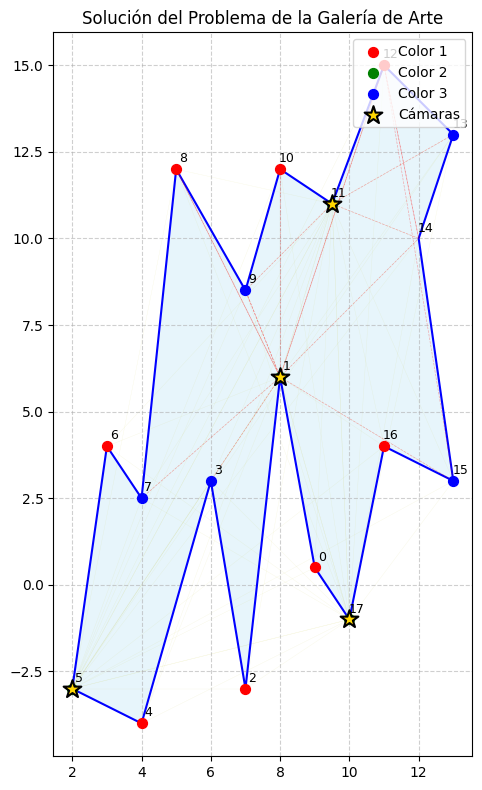

Solución: 4 cámaras en los vértices [1, 5, 11, 17]


In [200]:
# Asumiendo que ya tenemos:
# - dcel: La estructura DCEL del polígono
# - triangulos: Los triángulos resultantes de la triangulación

# Resolver el problema de la galería de arte
camaras = resolver_problema_galeria_arte(dcel, triangulos)

print(f"Solución: {len(camaras)} cámaras en los vértices {[dcel.vertices.index(v) for v in camaras]}")